# H-Neurons em Modelos de Linguagem de Pequena Escala
## Investigação da Existência de Neurônios Associados a Alucinações na Família Pythia

---

### Contexto e Motivação

Este notebook implementa e estende a metodologia proposta por **Gao et al. (2025)** no artigo *"H-Neurons: On the Existence, Impact, and Origin of Hallucination-Associated Neurons in LLMs"* (arXiv:2512.01797).

O artigo original demonstrou que, em LLMs grandes (7B–70B parâmetros), um subconjunto extremamente esparso de neurônios — menos de **0,1% do total** — consegue prever com alta acurácia se o modelo vai alucinar ou não. Esses neurônios foram denominados **H-Neurons** (Hallucination-associated Neurons).

A descoberta é feita "de dentro para fora": em vez de observar apenas o comportamento externo do modelo, o método mergulha nas ativações internas das camadas feedforward (FFN) para encontrar um sinal neural que precede a alucinação.

### A Lacuna que Este Projeto Preenche

O artigo original **só testou modelos grandes** (mínimo: Mistral-7B). Isso deixa uma pergunta sem resposta:

> **H-Neurons existem em modelos de pequena escala? Ou são um fenômeno emergente que só aparece acima de certo limiar de parâmetros?**

Este projeto investiga essa questão usando a família **Pythia** (EleutherAI), modelos de 70M, 160M e 410M parâmetros, projetados especificamente para pesquisa de interpretabilidade e viáveis em CPU.

### Hipóteses

- **H1 (Existência):** H-Neurons existem mesmo em modelos pequenos, indicando que o fenômeno é fundamental à arquitetura transformer.
- **H2 (Escala):** A acurácia do classificador baseado em H-Neurons aumenta com o tamanho do modelo, mesmo dentro da faixa pequena.
- **H3 (Generalização):** H-Neurons identificados com TriviaQA generalizam para domínios diferentes (NQ-Open).

### Como Usar Este Notebook

O notebook é estruturado em **10 blocos independentes**. Os blocos 0–9 devem ser rodados **um modelo por vez** (escolha o modelo na Célula 2.2). Após rodar os três modelos e salvar os resultados, o Bloco 10 realiza a análise comparativa.

**Ordem recomendada:**
1. Sessão 1: rodar com `pythia-70m` → salvar resultados
2. Sessão 2: rodar com `pythia-160m` → salvar resultados
3. Sessão 3: rodar com `pythia-410m` → salvar resultados
4. Sessão 4: rodar apenas o Bloco 10 para comparação

### Referências
- Gao et al. (2025). H-Neurons. arXiv:2512.01797
- Biderman et al. (2023). Pythia: A Suite for Analyzing Large Language Models. arXiv:2304.01373
- Joshi et al. (2017). TriviaQA. ACL 2017.

---

## Bloco 0.5 — Montagem do Google Drive

Este bloco monta o Google Drive na sessão do Colab e redireciona todos os caminhos de saída para uma pasta persistente no Drive.

**Por que isso é fundamental?**
O Colab gratuito encerra a sessão após ~90 minutos de inatividade ou ~12 horas no total. Sem o Drive montado, todos os arquivos salvos em `/content/` — incluindo o dataset contrastivo, as ativações extraídas e os resultados do classificador — são **permanentemente perdidos** quando a sessão cai. Com o Drive montado, esses arquivos ficam persistidos na sua conta Google e podem ser retomados em sessões futuras sem precisar re-executar o pipeline do zero.

**Estrutura de pastas criada no Drive:**
```
Meu Drive/
  h_neurons_project/
    pythia-70m_contrastive_dataset.json
    pythia-70m_cett_features.npz
    pythia-70m_h_neurons.json
    pythia-70m_metrics.json
    pythia-70m_final_results.json
    pythia-160m_*  /  pythia-410m_*
    fig1_accuracy_by_scale.png
    fig2_sparsity_by_scale.png
    fig3_h_neurons_by_layer.png
```

**Importante:** Execute este bloco **sempre** ao iniciar uma nova sessão do Colab, antes de qualquer outro bloco. Se os arquivos de sessões anteriores já existirem no Drive, os blocos subsequentes os reconhecerão automaticamente.


### Célula 0.5.1 — Montagem do Drive e Configuração de Paths

Monta o Google Drive e define o diretório raiz do projeto. O Colab pedirá permissão de acesso ao Drive — clique em **Conectar ao Google Drive** e autorize com sua conta Google.

Se preferir não usar o Drive (ex: experimento rápido ou ambiente local Jupyter), defina `USE_DRIVE = False`. Nesse caso os arquivos serão salvos em `/content/h_neurons_results/` e **serão perdidos** ao encerrar a sessão.


In [1]:
import os

# ============================================================
# DEFINA AQUI SE QUER USAR O GOOGLE DRIVE
# True  -> monta o Drive e salva tudo la (RECOMENDADO no Colab)
# False -> salva localmente no Colab (arquivos perdidos ao fechar sessao)
# ============================================================
USE_DRIVE = True

if USE_DRIVE:
    # Importa o modulo de integracao do Colab com o Google Drive
    # Ao executar, o Colab exibira um popup de autorizacao.
    # Clique em 'Conectar ao Google Drive' e faca login com sua conta.
    # Apos autorizar, o Drive estara disponivel em /content/drive/MyDrive/
    from google.colab import drive
    drive.mount('/content/drive')

    # Diretorio raiz do projeto no Drive.
    # Altere o nome da pasta se quiser organizar diferente.
    DRIVE_PROJECT_DIR = '/content/drive/MyDrive/IA376/h_neurons_project'

    # Cria a pasta do projeto no Drive caso ainda nao exista
    os.makedirs(DRIVE_PROJECT_DIR, exist_ok=True)

    # RESULTS_DIR e a variavel global usada por todos os blocos seguintes
    # para saber onde salvar e carregar arquivos
    RESULTS_DIR = DRIVE_PROJECT_DIR

    print('Drive montado com sucesso.')
    print(f'Arquivos do projeto serao salvos em: {RESULTS_DIR}')

    # Lista arquivos ja existentes (de sessoes anteriores)
    existing = sorted(os.listdir(RESULTS_DIR))
    if existing:
        print(f'\nArquivos encontrados de sessoes anteriores ({len(existing)} arquivos):')
        for fname in existing:
            fpath = os.path.join(RESULTS_DIR, fname)
            size_kb = os.path.getsize(fpath) / 1024
            print(f'  {fname}  ({size_kb:.1f} KB)')
    else:
        print('\nDiretorio vazio -- este e o primeiro experimento.')

else:
    # Sem Drive: salva localmente no Colab
    # ATENCAO: arquivos serao perdidos ao encerrar a sessao!
    RESULTS_DIR = '/content/drive/MyDrive/IA376/h_neurons_results'
    os.makedirs(RESULTS_DIR, exist_ok=True)
    print('AVISO: Google Drive NAO montado.')
    print(f'Arquivos salvos localmente em: {RESULTS_DIR}')
    print('ATENCAO: estes arquivos serao perdidos ao encerrar a sessao!')

print(f'\nRESULTS_DIR = {RESULTS_DIR}')


Mounted at /content/drive
Drive montado com sucesso.
Arquivos do projeto serao salvos em: /content/drive/MyDrive/IA376/h_neurons_project

Arquivos encontrados de sessoes anteriores (12 arquivos):
  .ipynb_checkpoints  (4.0 KB)
  pythia-1.4b_checkpoint.json  (50.6 KB)
  pythia-1b_checkpoint.json  (6.7 KB)
  pythia-410m_checkpoint.json  (39.7 KB)
  pythia-6.9b_activations.npz  (136908.8 KB)
  pythia-6.9b_cett_features.npz  (158186.2 KB)
  pythia-6.9b_checkpoint.json  (91.4 KB)
  pythia-6.9b_contrastive_dataset.json  (57.5 KB)
  pythia-6.9b_contrastive_dataset_fixed.json  (70.0 KB)
  pythia-6.9b_h_neurons.json  (2.0 KB)
  pythia-6.9b_metrics.json  (0.4 KB)
  pythia-6.9b_neuron_map.json  (54520.3 KB)

RESULTS_DIR = /content/drive/MyDrive/IA376/h_neurons_project


### Célula 0.5.2 — Verificação de Progresso de Sessões Anteriores

Verifica quais etapas já foram concluídas para cada modelo com base nos arquivos salvos no Drive. Isso permite retomar o experimento exatamente de onde parou, sem re-executar etapas já concluídas.

**Como usar a tabela de status:**
- `OK` = arquivo existe, etapa concluída, pode pular o bloco correspondente
- `--` = arquivo não existe, etapa pendente, precisa executar o bloco


In [2]:
import os

# Mapa de arquivos esperados por etapa do pipeline
# Chave: nome descritivo da etapa
# Valor: sufixo do arquivo gerado por aquela etapa
PIPELINE_STAGES = {
    'Dataset (Bloco 4)':   'contrastive_dataset.json',
    'Ativacoes (Bloco 5)': 'activations.npz',
    'CETT (Bloco 6)':      'cett_features.npz',
    'H-Neurons (Bloco 7)': 'h_neurons.json',
    'OOD (Bloco 8)':       'ood_results.json',
    'Final (Bloco 9)':     'final_results.json',
}

# Lista completa de modelos suportados + detecção automática
# de qualquer modelo com arquivos salvos no Drive
KNOWN_MODELS = [
    'pythia-70m',
    'pythia-160m',
    'pythia-410m',
    'pythia-1b',
    'pythia-1.4b',
    'pythia-2.8b',
    'pythia-6.9b',
    'pythia-12b',
]

# Detecta modelos com arquivos no Drive não listados acima
detected_models = set()
if os.path.exists(RESULTS_DIR):
    for fname in os.listdir(RESULTS_DIR):
        for suffix in PIPELINE_STAGES.values():
            if fname.endswith(suffix):
                model_name = fname.replace(f"_{suffix}", "")
                detected_models.add(model_name)

# Une lista conhecida com detectados — remove duplicatas mantendo ordem
all_models = list(dict.fromkeys(
    KNOWN_MODELS + sorted(detected_models - set(KNOWN_MODELS))
))

# Mostra apenas modelos que têm pelo menos um arquivo no Drive
# Os demais ficam ocultos para não poluir a tabela
models_to_show = [m for m in all_models if m in detected_models]

# Se nenhum arquivo encontrado ainda, mostra os três básicos
if not models_to_show:
    models_to_show = ['pythia-70m', 'pythia-160m', 'pythia-410m']

# Cabeçalho da tabela
stage_names = list(PIPELINE_STAGES.keys())
col_w = 18 + 22 * len(stage_names)
header = f"{'Modelo':<18}" + "".join(f"{s:<22}" for s in stage_names)

print("STATUS DO EXPERIMENTO")
print("=" * col_w)
print(header)
print("-" * col_w)

for model in models_to_show:
    row = f"{model:<18}"
    for stage, suffix in PIPELINE_STAGES.items():
        fpath = os.path.join(RESULTS_DIR, f"{model}_{suffix}")
        if os.path.exists(fpath):
            size_kb = os.path.getsize(fpath) / 1024
            status = f"OK ({size_kb:.0f}KB)"
        else:
            status = "--"
        row += f"{status:<22}"
    print(row)

print("=" * col_w)
print("\nOK = arquivo encontrado no Drive (etapa concluida)")
print("-- = arquivo nao encontrado (etapa pendente)")
print("\nDica: se 'Dataset' e 'CETT' forem OK, voce pode pular")
print("os Blocos 4, 5 e 6 nesta sessao e ir direto para o Bloco 7.")

STATUS DO EXPERIMENTO
Modelo            Dataset (Bloco 4)     Ativacoes (Bloco 5)   CETT (Bloco 6)        H-Neurons (Bloco 7)   OOD (Bloco 8)         Final (Bloco 9)       
------------------------------------------------------------------------------------------------------------------------------------------------------
pythia-6.9b       OK (58KB)             OK (136909KB)         OK (158186KB)         OK (2KB)              --                    --                    

OK = arquivo encontrado no Drive (etapa concluida)
-- = arquivo nao encontrado (etapa pendente)

Dica: se 'Dataset' e 'CETT' forem OK, voce pode pular
os Blocos 4, 5 e 6 nesta sessao e ir direto para o Bloco 7.


## Bloco 1 — Instalação e Imports

Este bloco prepara o ambiente de execução. Todas as dependências são instaladas e importadas aqui para garantir que o restante do notebook funcione sem interrupções.

**Bibliotecas principais:**
- `transformers`: carregamento dos modelos Pythia via HuggingFace
- `datasets`: acesso ao TriviaQA e NQ-Open diretamente da HuggingFace Hub
- `scikit-learn`: implementação do classificador logístico com regularização L1
- `torch`: manipulação de tensores e hooks para extração de ativações
- `matplotlib` / `seaborn`: visualizações dos resultados

### Célula 1.1 — Instalação das Dependências

Instala os pacotes necessários. O flag `-q` suprime a saída verbosa do pip. A célula só precisa ser executada uma vez por sessão do Colab — após isso, os pacotes ficam disponíveis até a sessão ser encerrada.

In [3]:
# Instalação silenciosa das dependências principais
# transformers: carregamento de modelos HuggingFace
# datasets: acesso a TriviaQA e NQ-Open
# scikit-learn: classificador L1 (LogisticRegression)
# tqdm: barras de progresso nos loops longos
# seaborn: visualizações estatísticas
!pip install -q transformers datasets scikit-learn tqdm seaborn

# Confirma instalação
!pip install -q transformers datasets scikit-learn tqdm seaborn
!pip install -q bitsandbytes>=0.46.1
from IPython.display import clear_output
clear_output()
print("✓ Dependências instaladas com sucesso.")

✓ Dependências instaladas com sucesso.


### Célula 1.2 — Imports e Configurações Globais

Importa todas as bibliotecas e define configurações globais de reprodutibilidade. A fixação de seeds em PyTorch, NumPy e Python garante que os resultados sejam idênticos entre execuções — fundamental para um experimento científico reproduzível.

In [4]:
# === Imports padrão ===
import os
import json
import random
import string
import re
import numpy as np
from pathlib import Path
from tqdm import tqdm

# === PyTorch ===
import torch
import torch.nn as nn

# === HuggingFace ===
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from datasets import load_dataset

# === Machine Learning ===
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
from sklearn.preprocessing import StandardScaler

# === Visualização ===
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# === Configuração de reprodutibilidade ===
# Fixar seeds garante que amostragens aleatórias sejam idênticas
# entre execuções diferentes do notebook
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# === Dispositivo ===
# Detecta automaticamente se há GPU disponível e a utiliza.
# Caso contrário, cai para CPU como fallback.
# GPU reduz significativamente o tempo de inferência:
#   Pythia-410M: ~4s/pergunta (CPU) → ~0.3s/pergunta (GPU T4)
#   Pythia-1.4B: ~10s/pergunta (CPU) → ~0.8s/pergunta (GPU T4)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Dispositivo configurado: {DEVICE}")
print(f"✓ Seed de reprodutibilidade: {SEED}")

# Informações adicionais sobre a GPU se disponível
if DEVICE.type == "cuda":
    print(f"✓ GPU detectada: {torch.cuda.get_device_name(0)}")
    print(f"✓ VRAM disponível: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠ GPU não disponível — usando CPU.")
    print("  Para ativar GPU no Colab: Ambiente de execução → Alterar tipo de ambiente de execução → GPU T4")

✓ Dispositivo configurado: cuda
✓ Seed de reprodutibilidade: 42
✓ GPU detectada: Tesla T4
✓ VRAM disponível: 15.6 GB


## Bloco 2 — Configuração do Experimento

Este bloco centraliza **todos os hiperparâmetros** do experimento em um único lugar. A vantagem dessa abordagem é que qualquer ajuste — mudar o modelo, aumentar o dataset, alterar a temperatura de amostragem — é feito aqui, sem precisar caçar valores espalhados pelo notebook.

O design em dicionário também facilita salvar a configuração junto com os resultados, garantindo rastreabilidade do experimento.

### Célula 2.1 — Parâmetros Globais do Experimento

Define o dicionário `CONFIG` com todos os hiperparâmetros. Cada parâmetro está comentado com sua justificativa, incluindo a referência ao artigo quando aplicável.

In [5]:
CONFIG = {

    # === Modelo ===
    # Será sobrescrito pela Célula 2.2 — definido aqui como fallback
    "model_id": "EleutherAI/pythia-6.9b",

    # === Geração de respostas ===
    # O artigo gera 10 amostras por pergunta e exige consistência total (10/10).
    # Mantemos 10 amostras; o threshold pode ser ajustado se o modelo for
    # muito pequeno e raramente acertar (ver discussão na Célula 4.3).
    "n_samples_per_question": 10,
    "consistency_threshold": 8,   # min acertos para "correto"; 0 para "incorreto"

    # === Dataset contrastivo ===
    # Buscamos N exemplos balanceados: N/2 corretos + N/2 incorretos.
    # O artigo usa 1000 (500+500). Iniciamos com 200 para viabilidade em CPU;
    # aumentar se o tempo permitir.
    "n_target_correct": 50,
    "n_target_incorrect": 50,

    # Limite de perguntas do TriviaQA a escanear antes de desistir.
    # Evita loops infinitos se o modelo for muito ruim ou muito bom.
    "max_questions_to_scan": 2000,

    # === Parâmetros de geração de texto ===
    # Seguindo o artigo: temperatura 1.0, top_k=50, top_p=0.9
    # para garantir diversidade entre as 10 amostras.
    "max_new_tokens": 32,    # respostas curtas — TriviaQA tem respostas concisas
    "temperature": 1.0,      # temperatura alta = mais diversidade entre amostras
    "top_k": 50,
    "top_p": 0.9,
    "do_sample": True,       # amostragem estocástica (não greedy) - gera respostas diferentes

    # === Classificador ===
    # Grid de valores de C (inverso da regularização L1) para busca.
    # C pequeno = mais esparsidade (menos neurônios selecionados).
    # C grande = menos esparsidade (mais neurônios, risco de ruído).
    # O artigo seleciona C que maximiza acurácia + desempenho sob supressão.
    "C_grid": [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
    "test_size": 0.2,        # 80% treino, 20% validação

    # === Paths de saída ===
    # Os resultados são salvos em disco para análise comparativa posterior.
    # Monte o Google Drive no Colab para persistência entre sessões.
    # Usa RESULTS_DIR definido no Bloco 0.5 (Google Drive ou local).
    # globals().get garante fallback seguro se o Bloco 0.5 nao foi executado.
    "results_dir": globals().get("RESULTS_DIR", "./h_neurons_results"),
}

# Cria diretório de resultados se não existir
Path(CONFIG["results_dir"]).mkdir(parents=True, exist_ok=True)

print("✓ Configuração carregada:")
for k, v in CONFIG.items():
    print(f"   {k}: {v}")

✓ Configuração carregada:
   model_id: EleutherAI/pythia-6.9b
   n_samples_per_question: 10
   consistency_threshold: 8
   n_target_correct: 50
   n_target_incorrect: 50
   max_questions_to_scan: 2000
   max_new_tokens: 32
   temperature: 1.0
   top_k: 50
   top_p: 0.9
   do_sample: True
   C_grid: [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
   test_size: 0.2
   results_dir: /content/drive/MyDrive/IA376/h_neurons_project


### Célula 2.2 — Seleção do Modelo

**Esta é a única célula que muda entre sessões.** Descomente o modelo que deseja rodar nesta sessão e mantenha os demais comentados. O restante do notebook se adapta automaticamente ao modelo escolhido.

**Ordem recomendada de execução:** 70M → 160M → 410M (do mais rápido para o mais lento).

In [6]:
# ============================================================
# SELECIONE O MODELO PARA ESTA SESSÃO
# Descomente APENAS UMA linha abaixo
# ============================================================

# --- Família Pythia — CPU (float32) ---
# CONFIG["model_id"] = "EleutherAI/pythia-70m"    # ~0.5GB RAM  | ~1h para 100 exemplos  | ⚠ taxa de acerto muito baixa no TriviaQA
# CONFIG["model_id"] = "EleutherAI/pythia-160m"   # ~1.0GB RAM  | ~2h para 100 exemplos
# CONFIG["model_id"] = "EleutherAI/pythia-410m"     # ~2.5GB RAM  | ~25min para 100 exemplos | ✓ executado e validado

# --- Família Pythia — GPU recomendada (float32 ou 4-bit) ---
# CONFIG["model_id"] = "EleutherAI/pythia-1b"     # ~4.0GB RAM  | ~10s/pergunta CPU | ~0.5s/pergunta GPU
# CONFIG["model_id"] = "EleutherAI/pythia-1.4b"   # ~6.0GB RAM  | ~15s/pergunta CPU | ~0.8s/pergunta GPU
# CONFIG["model_id"] = "EleutherAI/pythia-2.8b"   # ~11.0GB RAM | GPU obrigatória   | ~1.5s/pergunta GPU T4
CONFIG["model_id"] = "EleutherAI/pythia-6.9b"   # ~28.0GB RAM | GPU obrigatória   | ⚠ risco de OOM no Colab gratuito
# CONFIG["model_id"] = "EleutherAI/pythia-12b"    # ~48.0GB RAM | GPU obrigatória   | ✗ inviável no Colab gratuito

# Nome curto para usar em nomes de arquivo (ex: "pythia-410m")
MODEL_SHORT = CONFIG["model_id"].split("/")[-1]

print(f"✓ Modelo selecionado: {CONFIG['model_id']}")
print(f"✓ Identificador curto: {MODEL_SHORT}")
print(f"✓ Dispositivo ativo: {DEVICE}")
print(f"✓ Resultados serão salvos em: {CONFIG['results_dir']}/{MODEL_SHORT}_*")

# Aviso se modelo grande for selecionado em CPU
large_models = ["pythia-1b", "pythia-1.4b", "pythia-2.8b", "pythia-6.9b", "pythia-12b"]
if any(m in CONFIG["model_id"] for m in large_models) and DEVICE.type == "cpu":
    print(f"\n⚠ ATENÇÃO: {MODEL_SHORT} em CPU pode ser muito lento.")
    print("  Considere ativar GPU: Ambiente de execução → Alterar tipo de ambiente de execução → GPU T4")

✓ Modelo selecionado: EleutherAI/pythia-6.9b
✓ Identificador curto: pythia-6.9b
✓ Dispositivo ativo: cuda
✓ Resultados serão salvos em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_*


## Bloco 3 — Carregamento do Modelo

Este bloco carrega o modelo Pythia selecionado e inspeciona sua arquitetura interna, com foco nas camadas FFN (feedforward networks) — que são exatamente onde os H-Neurons residem.

**Por que focar nas camadas FFN?**
Em modelos transformer, as camadas FFN funcionam como memórias de conhecimento — é onde o modelo "armazena" fatos durante o pré-treino. O artigo demonstra que os neurônios nessas camadas são os responsáveis pelos padrões de alucinação. As camadas de atenção, por outro lado, lidam com o roteamento de informação entre tokens, não com o conteúdo factual em si.

### Célula 3.1 — Carregamento do Tokenizer e Modelo

Carrega o tokenizer e o modelo Pythia selecionado com estratégia adaptativa:
quando GPU está disponível, utiliza quantização 4-bit (nf4) via BitsAndBytes,
reduzindo o uso de VRAM à metade com impacto mínimo na precisão. Quando apenas
CPU está disponível, carrega em float32 sem quantização.

A estratégia de carregamento é escolhida automaticamente com base no dispositivo
detectado na Célula 1.2 — nenhuma alteração manual é necessária aqui.

Referência de uso de memória e tempo estimado por modelo:

| Modelo        | CPU — RAM (float32) | GPU — VRAM (4-bit) | Tempo/pergunta CPU | Tempo/pergunta GPU T4 |
|---------------|---------------------|--------------------|--------------------|-----------------------|
| Pythia-70M    | ~0,5 GB             | —                  | ~1s                | ~0,1s                 |
| Pythia-160M   | ~1,0 GB             | —                  | ~2s                | ~0,2s                 |
| Pythia-410M   | ~2,5 GB             | ~0,2 GB            | ~4s                | ~0,3s                 |
| Pythia-1B     | ~4,0 GB             | ~0,5 GB            | ~8s                | ~0,5s                 |
| Pythia-1.4B   | ~6,0 GB             | ~0,7 GB            | ~12s               | ~0,8s                 |
| Pythia-2.8B   | ~11,0 GB            | ~1,4 GB            | ~25s               | ~1,5s                 |
| Pythia-6.9B   | ✗ inviável          | ~3,5 GB            | —                  | ~3,0s                 |
| Pythia-12B    | ✗ inviável          | ~6,0 GB            | —                  | ~5,0s                 |

**Recomendações:**
- Modelos ≤ 410M: CPU é suficiente
- Modelos ≥ 1B: GPU recomendada para viabilizar o experimento em tempo hábil
- Modelos ≥ 6.9B: GPU obrigatória — CPU inviável por limite de RAM
- Colab gratuito (GPU T4, 15GB VRAM): suporta até Pythia-2.8B com quantização 4-bit

In [7]:
# #####
# ########### USAR APENAS CPU
# #####

# print(f"Carregando tokenizer: {CONFIG['model_id']}...")

# # Carrega o tokenizer — responsável por converter texto em IDs de tokens
# # e vice-versa. O Pythia usa o mesmo tokenizer do GPT-NeoX.
# tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_id"])

# # O Pythia não tem padding token por padrão (é um modelo de geração).
# # Adicionamos o EOS token como padding para permitir batches.
# # Isso não afeta a geração — só é usado quando precisamos de tensores
# # de tamanho fixo.
# if tokenizer.pad_token is None:
#     tokenizer.pad_token = tokenizer.eos_token

# print(f"✓ Tokenizer carregado. Vocabulário: {tokenizer.vocab_size} tokens")
# print(f"\nCarregando modelo: {CONFIG['model_id']}...")

# # === Estratégia de carregamento baseada no dispositivo disponível ===
# #
# # GPU disponível → float16 sem quantização
# #   Meia precisão é mais rápida que 4-bit para modelos pequenos (≤ 2.8B)
# #   porque elimina o overhead de dequantização a cada forward pass.
# #   Mais fiel à metodologia original de Gao et al. (2025), que roda
# #   os modelos em precisão completa.
# #   device_map="auto" aloca o modelo inteiro na GPU quando há VRAM
# #   suficiente, ou distribui entre GPU e CPU se necessário.
# #   Referência de VRAM em float16:
# #     Pythia-410M: ~0,8 GB | Pythia-1B: ~2,0 GB | Pythia-1.4B: ~2,8 GB
# #     Pythia-2.8B: ~5,6 GB | Pythia-6.9B: ~13,8 GB (limite T4)
# #
# # CPU → float32 sem quantização
# #   Quantização requer CUDA e não funciona em CPU.
# #   low_cpu_mem_usage=True carrega os pesos de forma incremental,
# #   reduzindo o pico de uso de RAM durante o carregamento.

# if DEVICE.type == "cuda":
#     print("✓ GPU detectada — carregando em float16 sem quantização...")
#     print("  (float16 é mais rápido e mais fiel à metodologia original que 4-bit)")
#     model = AutoModelForCausalLM.from_pretrained(
#         CONFIG["model_id"],
#         torch_dtype=torch.float16,  # meia precisão — sem overhead de dequantização
#         device_map="auto",          # aloca automaticamente na GPU
#     )
# else:
#     print("⚠ CPU detectada — carregando em float32 sem quantização...")
#     model = AutoModelForCausalLM.from_pretrained(
#         CONFIG["model_id"],
#         torch_dtype=torch.float32,
#         low_cpu_mem_usage=True,     # carregamento incremental — reduz pico de RAM
#     )
#     # Move explicitamente para CPU
#     # (com device_map="auto" em GPU isso é feito automaticamente)
#     model = model.to(DEVICE)

# # Coloca o modelo em modo de avaliação (desativa dropout, batch norm, etc.)
# # Fundamental para experimentos de interpretabilidade — queremos o
# # comportamento determinístico do modelo, não o comportamento de treino.
# model.eval()

# # Conta parâmetros totais e estima uso de memória
# total_params = sum(p.numel() for p in model.parameters())
# mem_float32 = total_params * 4 / 1e6   # estimativa em float32 (MB)
# mem_float16 = total_params * 2 / 1e6   # estimativa em float16 (MB)

# print(f"✓ Modelo carregado em modo eval.")
# print(f"   Parâmetros totais:        {total_params:,}")
# print(f"   Memória (float32):   ~{mem_float32:.0f} MB")
# print(f"   Memória (float16):   ~{mem_float16:.0f} MB")
# if DEVICE.type == "cuda":
#     print(f"   VRAM alocada:        {torch.cuda.memory_allocated()/1e6:.0f} MB")
#     print(f"   VRAM reservada:      {torch.cuda.memory_reserved()/1e6:.0f} MB")



####
######## USAR COM GPU + CPU (ATENTAR PARA N_GPU_LAYERS)
####



import os
import gc
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoConfig,
    BitsAndBytesConfig,
)

# Deve vir antes de carregar o modelo
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

gc.collect()
torch.cuda.empty_cache()

model_id = CONFIG["model_id"]

print(f"Carregando tokenizer: {model_id}...")
tokenizer = AutoTokenizer.from_pretrained(model_id)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Carregando configuração: {model_id}...")
config = AutoConfig.from_pretrained(model_id)

n_layers = config.num_hidden_layers
print(f"Número de camadas Transformer: {n_layers}")

# ============================================================
# Ajuste principal
# ============================================================
# Para Pythia-6.9B no Colab com ~15 GB de VRAM,
# comece com algo conservador.
#
# Se ainda der OOM, reduza para 12, 10 ou 8.
# Se sobrar VRAM, aumente para 18, 20, 22...
N_GPU_LAYERS = 24

device_map = {}

# Embedding na GPU
device_map["gpt_neox.embed_in"] = 0

# Blocos Transformer
for i in range(n_layers):
    if i < N_GPU_LAYERS:
        device_map[f"gpt_neox.layers.{i}"] = 0
    else:
        device_map[f"gpt_neox.layers.{i}"] = "cpu"

# Normalização final na GPU
device_map["gpt_neox.final_layer_norm"] = 0

# Cabeça de saída na CPU para economizar VRAM
device_map["embed_out"] = "cpu"

print("Device map:")
for k, v in device_map.items():
    print(f"{k}: {v}")

# ============================================================
# Quantização 8-bit com CPU offload
# ============================================================
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_enable_fp32_cpu_offload=True,
)

print("Carregando modelo em 8-bit com offload CPU/GPU...")

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map=device_map,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
)

model.eval()
model.config.use_cache = False

print("✓ Modelo carregado.")
print("Device map real:")
print(model.hf_device_map)

print(f"Memória do modelo: {model.get_memory_footprint()/1e9:.2f} GB")

if torch.cuda.is_available():
    print(f"VRAM alocada: {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"VRAM reservada: {torch.cuda.memory_reserved()/1e9:.2f} GB")

Carregando tokenizer: EleutherAI/pythia-6.9b...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

✓ Modelo carregado.
Device map real:
{'gpt_neox.embed_in': 0, 'gpt_neox.layers.0': 0, 'gpt_neox.layers.1': 0, 'gpt_neox.layers.2': 0, 'gpt_neox.layers.3': 0, 'gpt_neox.layers.4': 0, 'gpt_neox.layers.5': 0, 'gpt_neox.layers.6': 0, 'gpt_neox.layers.7': 0, 'gpt_neox.layers.8': 0, 'gpt_neox.layers.9': 0, 'gpt_neox.layers.10': 0, 'gpt_neox.layers.11': 0, 'gpt_neox.layers.12': 0, 'gpt_neox.layers.13': 0, 'gpt_neox.layers.14': 0, 'gpt_neox.layers.15': 0, 'gpt_neox.layers.16': 0, 'gpt_neox.layers.17': 0, 'gpt_neox.layers.18': 0, 'gpt_neox.layers.19': 0, 'gpt_neox.layers.20': 0, 'gpt_neox.layers.21': 0, 'gpt_neox.layers.22': 0, 'gpt_neox.layers.23': 0, 'gpt_neox.layers.24': 'cpu', 'gpt_neox.layers.25': 'cpu', 'gpt_neox.layers.26': 'cpu', 'gpt_neox.layers.27': 'cpu', 'gpt_neox.layers.28': 'cpu', 'gpt_neox.layers.29': 'cpu', 'gpt_neox.layers.30': 'cpu', 'gpt_neox.layers.31': 'cpu', 'gpt_neox.final_layer_norm': 0, 'embed_out': 'cpu'}
Memória do modelo: 8.88 GB
VRAM alocada: 5.25 GB
VRAM reservada:

In [8]:
# #####
# ########### USAR APENAS CPU
# #####


# print(f"Carregando tokenizer: {CONFIG['model_id']}...")

# # Carrega o tokenizer — responsável por converter texto em IDs de tokens
# # e vice-versa. O Pythia usa o mesmo tokenizer do GPT-NeoX.
# tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_id"])

# # O Pythia não tem padding token por padrão (é um modelo de geração).
# # Adicionamos o EOS token como padding para permitir batches.
# # Isso não afeta a geração — só é usado quando precisamos de tensores
# # de tamanho fixo.
# if tokenizer.pad_token is None:
#     tokenizer.pad_token = tokenizer.eos_token

# print(f"✓ Tokenizer carregado. Vocabulário: {tokenizer.vocab_size} tokens")
# print(f"\nCarregando modelo: {CONFIG['model_id']}...")

# # === Estratégia de carregamento baseada no dispositivo disponível ===
# #
# # GPU disponível → quantização 4-bit (BitsAndBytes)
# #   Reduz o uso de VRAM pela metade mantendo boa precisão numérica.
# #   nf4 (NormalFloat4) é o formato recomendado para LLMs.
# #   compute_dtype=float16 garante que os cálculos intermediários
# #   sejam feitos em meia precisão, não em int4 puro.
# #   device_map="auto" distribui o modelo automaticamente entre
# #   GPU e CPU se necessário (útil para modelos maiores).
# #
# # CPU → float32 sem quantização
# #   Quantização 4-bit requer CUDA e não funciona em CPU.
# #   low_cpu_mem_usage=True carrega os pesos de forma incremental,
# #   reduzindo o pico de uso de RAM durante o carregamento.

# if DEVICE.type == "cuda":
#     print("✓ GPU detectada — carregando com quantização 4-bit (nf4)...")
#     bnb_config = BitsAndBytesConfig(
#         load_in_4bit=True,
#         bnb_4bit_quant_type="nf4",              # NormalFloat4 — melhor para LLMs
#         bnb_4bit_compute_dtype=torch.float16,   # cálculos em float16
#         bnb_4bit_use_double_quant=True,         # quantização dupla — menos VRAM
#     )
#     model = AutoModelForCausalLM.from_pretrained(
#         CONFIG["model_id"],
#         quantization_config=bnb_config,
#         device_map="auto",                      # distribui automaticamente na GPU
#     )
# else:
#     print("⚠ CPU detectada — carregando em float32 sem quantização...")
#     model = AutoModelForCausalLM.from_pretrained(
#         CONFIG["model_id"],
#         torch_dtype=torch.float32,
#         low_cpu_mem_usage=True,                 # carregamento incremental
#     )
#     # Move explicitamente para CPU
#     # (com device_map="auto" em GPU isso é feito automaticamente)
#     model = model.to(DEVICE)

# # Coloca o modelo em modo de avaliação (desativa dropout, batch norm, etc.)
# # Fundamental para experimentos de interpretabilidade — queremos o
# # comportamento determinístico do modelo, não o comportamento de treino.
# model.eval()

# # Conta parâmetros totais e estima uso de memória
# total_params = sum(p.numel() for p in model.parameters())
# mem_float32 = total_params * 4 / 1e6   # estimativa em float32
# mem_4bit    = total_params * 0.5 / 1e6 # estimativa em 4-bit

# print(f"✓ Modelo carregado em modo eval.")
# print(f"   Parâmetros totais:       {total_params:,}")
# print(f"   Memória (float32):  ~{mem_float32:.0f} MB")
# if DEVICE.type == "cuda":
#     print(f"   Memória (4-bit):    ~{mem_4bit:.0f} MB (quantizado)")
#     print(f"   VRAM usada:         {torch.cuda.memory_allocated()/1e6:.0f} MB")


#####
########### USAR COM GPU + CPU (ATENTAR PARA N_GPU_LAYERS)
#####


import os
import gc
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoConfig,
    BitsAndBytesConfig,
)

# Ajuda a reduzir problemas de fragmentação de memória CUDA
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print(f"Carregando tokenizer: {CONFIG['model_id']}...")

tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_id"])

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"✓ Tokenizer carregado. Vocabulário: {tokenizer.vocab_size} tokens")
print(f"\nCarregando modelo: {CONFIG['model_id']}...")

# ============================================================
# Configuração do modelo
# ============================================================

config = AutoConfig.from_pretrained(CONFIG["model_id"])
n_layers = config.num_hidden_layers

print(f"✓ Número de camadas Transformer: {n_layers}")

# Você disse que conseguiu rodar com 24 camadas na GPU.
# Para o Pythia-6.9B, isso deixa as camadas restantes na CPU/RAM.
N_GPU_LAYERS = 24

# ============================================================
# Estratégia de carregamento
# ============================================================
#
# GPU disponível:
#   Usamos quantização 8-bit com CPU offload.
#
#   Por que não 4-bit aqui?
#   Porque, no seu caso, o modelo não coube inteiro em 4-bit na GPU.
#   Quando o modelo precisa ser dividido entre GPU e CPU, o caminho
#   mais estável com BitsAndBytes é 8-bit + llm_int8_enable_fp32_cpu_offload.
#
# CPU:
#   Carrega em float32 sem quantização.
#
# Observação importante:
#   NÃO use model.to(DEVICE) quando device_map é usado.
#   O device_map já define onde cada parte do modelo fica.

if DEVICE.type == "cuda":

    print("✓ GPU detectada — carregando em 8-bit com CPU offload...")

    bnb_config = BitsAndBytesConfig(
        load_in_8bit=True,
        llm_int8_enable_fp32_cpu_offload=True,
    )

    # ========================================================
    # Device map manual
    # ========================================================
    #
    # Camadas 0 até N_GPU_LAYERS-1 vão para GPU.
    # Camadas restantes vão para CPU.
    #
    # Como as últimas camadas ficam na CPU, também deixamos
    # final_layer_norm e embed_out na CPU para evitar transferências extras.

    device_map = {}

    # Embedding inicial na GPU
    device_map["gpt_neox.embed_in"] = 0

    # Blocos Transformer
    for i in range(n_layers):
        if i < N_GPU_LAYERS:
            device_map[f"gpt_neox.layers.{i}"] = 0
        else:
            device_map[f"gpt_neox.layers.{i}"] = "cpu"

    # Como as últimas camadas estão na CPU, mantemos a saída na CPU
    device_map["gpt_neox.final_layer_norm"] = "cpu"
    device_map["embed_out"] = "cpu"

    print("\nDevice map planejado:")
    print(f"  Camadas na GPU: 0 até {N_GPU_LAYERS - 1}")
    print(f"  Camadas na CPU: {N_GPU_LAYERS} até {n_layers - 1}")
    print("  final_layer_norm: CPU")
    print("  embed_out: CPU")

    model = AutoModelForCausalLM.from_pretrained(
        CONFIG["model_id"],
        quantization_config=bnb_config,
        device_map=device_map,
        torch_dtype=torch.float16,
        low_cpu_mem_usage=True,
    )

else:

    print("⚠ CPU detectada — carregando em float32 sem quantização...")

    model = AutoModelForCausalLM.from_pretrained(
        CONFIG["model_id"],
        torch_dtype=torch.float32,
        low_cpu_mem_usage=True,
    )

    model = model.to(DEVICE)

# ============================================================
# Modo de avaliação
# ============================================================

model.eval()

# Recomendado para interpretabilidade / extração de ativações,
# pois reduz memória associada ao cache de KV.
model.config.use_cache = False

# ============================================================
# Estatísticas de memória
# ============================================================

total_params = sum(p.numel() for p in model.parameters())

mem_float32 = total_params * 4 / 1e6
mem_float16 = total_params * 2 / 1e6
mem_8bit    = total_params * 1 / 1e6
mem_4bit    = total_params * 0.5 / 1e6

print("\n✓ Modelo carregado em modo eval.")
print(f"   Parâmetros totais:        {total_params:,}")
print(f"   Memória teórica float32: ~{mem_float32:.0f} MB")
print(f"   Memória teórica float16: ~{mem_float16:.0f} MB")
print(f"   Memória teórica 8-bit:   ~{mem_8bit:.0f} MB")
print(f"   Memória teórica 4-bit:   ~{mem_4bit:.0f} MB")

if DEVICE.type == "cuda":
    print(f"   VRAM alocada:            {torch.cuda.memory_allocated()/1e6:.0f} MB")
    print(f"   VRAM reservada:          {torch.cuda.memory_reserved()/1e6:.0f} MB")
    print(f"   Pico de VRAM alocada:    {torch.cuda.max_memory_allocated()/1e6:.0f} MB")

    print("\nDevice map real usado pelo modelo:")
    print(model.hf_device_map)

    print(f"\nMemória estimada pelo modelo: {model.get_memory_footprint()/1e9:.2f} GB")

Carregando tokenizer: EleutherAI/pythia-6.9b...
✓ Tokenizer carregado. Vocabulário: 50254 tokens

Carregando modelo: EleutherAI/pythia-6.9b...
✓ Número de camadas Transformer: 32
✓ GPU detectada — carregando em 8-bit com CPU offload...

Device map planejado:
  Camadas na GPU: 0 até 23
  Camadas na CPU: 24 até 31
  final_layer_norm: CPU
  embed_out: CPU


Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]


✓ Modelo carregado em modo eval.
   Parâmetros totais:        6,857,302,016
   Memória teórica float32: ~27429 MB
   Memória teórica float16: ~13715 MB
   Memória teórica 8-bit:   ~6857 MB
   Memória teórica 4-bit:   ~3429 MB
   VRAM alocada:            10502 MB
   VRAM reservada:          13476 MB
   Pico de VRAM alocada:    14459 MB

Device map real usado pelo modelo:
{'gpt_neox.embed_in': 0, 'gpt_neox.layers.0': 0, 'gpt_neox.layers.1': 0, 'gpt_neox.layers.2': 0, 'gpt_neox.layers.3': 0, 'gpt_neox.layers.4': 0, 'gpt_neox.layers.5': 0, 'gpt_neox.layers.6': 0, 'gpt_neox.layers.7': 0, 'gpt_neox.layers.8': 0, 'gpt_neox.layers.9': 0, 'gpt_neox.layers.10': 0, 'gpt_neox.layers.11': 0, 'gpt_neox.layers.12': 0, 'gpt_neox.layers.13': 0, 'gpt_neox.layers.14': 0, 'gpt_neox.layers.15': 0, 'gpt_neox.layers.16': 0, 'gpt_neox.layers.17': 0, 'gpt_neox.layers.18': 0, 'gpt_neox.layers.19': 0, 'gpt_neox.layers.20': 0, 'gpt_neox.layers.21': 0, 'gpt_neox.layers.22': 0, 'gpt_neox.layers.23': 0, 'gpt_neox.l

### Célula 3.2 — Inspeção da Arquitetura FFN

Mapeia programaticamente todas as camadas FFN do modelo. Esse mapa é essencial para as etapas seguintes: precisamos saber exatamente onde registrar os hooks de extração de ativações.

No Pythia, cada bloco transformer tem uma subcamada FFN com a estrutura:
- **Projeção de entrada** (`dense_h_to_4h`): expande a dimensão oculta para uma dimensão intermediária maior
- **Ativação não-linear** (GeLU)
- **Projeção de saída** (`dense_4h_to_h`): retorna à dimensão oculta original

Os "neurônios" são as unidades na dimensão intermediária — cada neurônio corresponde a uma posição no vetor de ativação após a projeção de entrada e antes da projeção de saída.

In [9]:
# Dicionário que mapeia cada camada FFN:
# chave: nome da camada (ex: "gpt_neox.layers.0.mlp")
# valor: dicionário com informações da camada
FFN_LAYER_MAP = {}

# Contador global de neurônios FFN
total_ffn_neurons = 0

print("Mapeando camadas FFN do modelo...\n")
print(f"{'Índice':<8} {'Nome da Camada':<45} {'Dim. Oculta':<15} {'Dim. Intermediária':<20} {'Neurônios':<12}")
print("-" * 100)

# Itera sobre todos os módulos nomeados do modelo
# named_modules() retorna pares (nome, módulo) de forma recursiva
layer_idx = 0
for name, module in model.named_modules():

    # No Pythia (GPT-NeoX), as camadas MLP têm o atributo 'dense_h_to_4h'
    # que é a projeção de entrada da FFN.
    # Identificamos a camada FFN pelo módulo pai que contém essa projeção.
    if hasattr(module, 'dense_h_to_4h') and hasattr(module, 'dense_4h_to_h'):

        # Dimensões da FFN
        hidden_size = module.dense_h_to_4h.in_features   # dimensão de entrada
        intermediate_size = module.dense_h_to_4h.out_features  # dimensão intermediária

        # Cada posição na dimensão intermediária é um "neurônio" no sentido do artigo
        n_neurons = intermediate_size
        total_ffn_neurons += n_neurons

        FFN_LAYER_MAP[name] = {
            "index": layer_idx,
            "name": name,
            "hidden_size": hidden_size,
            "intermediate_size": intermediate_size,
            "n_neurons": n_neurons,
            "module": module,  # referência ao módulo para registrar hooks
        }

        print(f"{layer_idx:<8} {name:<45} {hidden_size:<15} {intermediate_size:<20} {n_neurons:<12}")
        layer_idx += 1

print("-" * 100)
print(f"\n✓ Total de camadas FFN encontradas: {len(FFN_LAYER_MAP)}")
print(f"✓ Total de neurônios FFN: {total_ffn_neurons:,}")
print(f"✓ 0.1% dos neurônios = {int(total_ffn_neurons * 0.001):,} neurônios")
print(f"  (limiar de esparsidade esperado para H-Neurons segundo o artigo)")

# Salva o mapa no CONFIG para uso nas células seguintes
CONFIG["total_ffn_neurons"] = total_ffn_neurons
CONFIG["n_ffn_layers"] = len(FFN_LAYER_MAP)

Mapeando camadas FFN do modelo...

Índice   Nome da Camada                                Dim. Oculta     Dim. Intermediária   Neurônios   
----------------------------------------------------------------------------------------------------
0        gpt_neox.layers.0.mlp                         4096            16384                16384       
1        gpt_neox.layers.1.mlp                         4096            16384                16384       
2        gpt_neox.layers.2.mlp                         4096            16384                16384       
3        gpt_neox.layers.3.mlp                         4096            16384                16384       
4        gpt_neox.layers.4.mlp                         4096            16384                16384       
5        gpt_neox.layers.5.mlp                         4096            16384                16384       
6        gpt_neox.layers.6.mlp                         4096            16384                16384       
7        gpt_neox.layers

## Bloco 4 — Construção do Dataset Contrastivo

Este é o bloco mais importante do pipeline — e o mais demorado. O objetivo é construir um dataset balanceado de respostas **consistentemente corretas** e **consistentemente incorretas**.

**Por que exigir consistência?**
Modelos de linguagem usam amostragem estocástica (temperatura > 0), então a mesma pergunta pode gerar respostas diferentes em execuções distintas. Se usássemos uma única amostra por pergunta, não saberíamos se o modelo "sabe" ou "não sabe" a resposta — ou se apenas teve sorte/azar naquela geração específica.

Ao exigir que o modelo acerte (ou erre) **todas as N amostras**, garantimos que estamos capturando padrões estáveis de ativação, não ruído de geração.

**Implicação para modelos pequenos:**
Modelos de 70M–410M parâmetros têm capacidade factual muito limitada. É esperado que a maioria das perguntas do TriviaQA sejam erradas consistentemente. Isso não é um problema — precisamos apenas de um número suficiente de perguntas corretas para equilibrar o dataset.

### Célula 4.1 — Carregamento do TriviaQA

Carrega o split de validação do TriviaQA. Usamos validação (não treino) porque é menor e suficiente para nosso propósito. O TriviaQA é ideal para este experimento: perguntas factuais concisas com respostas verificáveis — exatamente o tipo de tarefa onde alucinações são fáceis de detectar.

In [10]:
print("Carregando TriviaQA (split de validação)...")

# Carrega o TriviaQA na configuração 'rc' (reading comprehension).
# O split 'validation' tem ~11k perguntas — mais do que suficiente
# para encontrar os 200 exemplos balanceados que buscamos.
# trust_remote_code=True é necessário para alguns datasets no HuggingFace.
trivia_dataset = load_dataset(
    "trivia_qa",
    "rc.nocontext",       # versão sem contexto — o modelo responde de memória
    split="validation",
    trust_remote_code=True,
)

print(f"✓ TriviaQA carregado: {len(trivia_dataset):,} perguntas")
print("\nExemplo de entrada:")

# Mostra um exemplo para inspeção
exemplo = trivia_dataset[0]
print(f"  Pergunta: {exemplo['question']}")
print(f"  Resposta principal: {exemplo['answer']['value']}")
print(f"  Aliases aceitos: {exemplo['answer']['aliases'][:5]}...")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'trivia_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'trivia_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Carregando TriviaQA (split de validação)...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

rc.nocontext/train-00000-of-00001.parque(…):   0%|          | 0.00/55.4M [00:00<?, ?B/s]

...

rc.nocontext/test-00000-of-00001.parquet:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/138384 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/17944 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/17210 [00:00<?, ? examples/s]

✓ TriviaQA carregado: 17,944 perguntas

Exemplo de entrada:
  Pergunta: Who was the man behind The Chipmunks?
  Resposta principal: David Seville
  Aliases aceitos: ['David Seville']...


### Célula 4.2 — Funções de Avaliação de Resposta

Implementa as duas métricas de match usadas para avaliar se a resposta gerada pelo modelo é correta:

- **Exact Match:** a resposta gerada é textualmente idêntica a uma das respostas aceitas
- **Flexible Match:** após normalização (lowercase, remoção de artigos e pontuação), a resposta coincide

O Flexible Match é mais robusto para modelos que respondem corretamente mas com formatação diferente (ex: "Shakespeare" vs "William Shakespeare"). Ambas as métricas são aplicadas — se qualquer uma for verdadeira, a resposta é considerada correta.

In [11]:
def normalize_text(text: str) -> str:
    """
    Normaliza texto para comparação flexible.
    Remove artigos, pontuação, espaços extras e converte para lowercase.
    Segue a normalização padrão usada em benchmarks de QA (ex: SQuAD, TriviaQA).
    """
    # Converte para minúsculas
    text = text.lower()

    # Remove artigos no início ou após espaço
    # Cobre inglês: 'the', 'a', 'an'
    text = re.sub(r'\b(a|an|the)\b', ' ', text)

    # Remove pontuação (tudo que não é letra, número ou espaço)
    text = re.sub(r'[^\w\s]', '', text)

    # Remove espaços extras gerados pelas remoções anteriores
    text = ' '.join(text.split())

    return text.strip()


def evaluate_answer(generated: str, gold_answers: list) -> dict:
    """
    Avalia se a resposta gerada é correta em relação às respostas aceitas.

    Args:
        generated: texto gerado pelo modelo (resposta)
        gold_answers: lista de respostas aceitas (value + aliases do TriviaQA)

    Returns:
        dict com 'exact_match' e 'flexible_match' (ambos bool),
        e 'is_correct' (True se qualquer um for verdadeiro)
    """
    # Normaliza a resposta gerada
    gen_norm = normalize_text(generated)

    exact = False
    flexible = False

    for gold in gold_answers:
        gold_str = str(gold)
        gold_norm = normalize_text(gold_str)

        # Exact match: a gold answer está contida na resposta gerada
        # (usamos 'in' em vez de '==' porque o modelo pode gerar
        # frases completas como "A resposta é Shakespeare")
        if gold_str.lower() in generated.lower():
            exact = True

        # Flexible match: comparação após normalização
        if gold_norm and gold_norm in gen_norm:
            flexible = True

        # Para respostas de uma palavra, evita falso positivo por substring.
        # Exemplo ruim que evitamos: gold = "us" dentro de "russia".
        if len(gold_norm.split()) == 1:
            gen_words = gen_norm.split()
            if gold_norm in gen_words:
                flexible = True
                matched_gold = gold_str

        # Otimização: para de comparar se já encontrou match
        if exact and flexible:
            break

    return {
        "exact_match": exact,
        "flexible_match": flexible,
        "is_correct": exact or flexible,  # correto se qualquer critério for True
    }


def extract_gold_answers(item: dict) -> list:
    """
    Extrai todas as respostas aceitas de um item do TriviaQA.
    O TriviaQA armazena a resposta principal em 'value' e
    variações aceitas em 'aliases'.
    """
    answers = [item["answer"]["value"]]           # resposta principal
    answers += item["answer"].get("aliases", [])   # variações aceitas
    return [a for a in answers if a]               # remove strings vazias


# Teste rápido das funções
print("Testando funções de avaliação...")
test_generated = "The play Hamlet was written by Shakespeare in the early 1600s."
test_gold = ["William Shakespeare", "Shakespeare"]
result = evaluate_answer(test_generated, test_gold)
print(f"  Gerado: '{test_generated}'")
print(f"  Gold: {test_gold}")
print(f"  Resultado: {result}")
print("\n✓ Funções de avaliação prontas.")



Testando funções de avaliação...
  Gerado: 'The play Hamlet was written by Shakespeare in the early 1600s.'
  Gold: ['William Shakespeare', 'Shakespeare']
  Resultado: {'exact_match': True, 'flexible_match': True, 'is_correct': True}

✓ Funções de avaliação prontas.


### Célula 4.3 — Geração do Dataset Contrastivo

Este é o loop principal de construção do dataset. Para cada pergunta do TriviaQA:

1. Gera `N_SAMPLES_PER_QUESTION` respostas com amostragem estocástica
2. Avalia cada resposta contra as respostas aceitas
3. Aplica o filtro de consistência (todas certas OU todas erradas)
4. Adiciona ao dataset correto ou incorreto conforme o caso
5. Para quando atingir o balanço alvo

**Nota sobre velocidade:** em CPU, cada pergunta leva ~5–20 segundos (dependendo do modelo e do comprimento da resposta). Para 200 exemplos, estime 1–5 horas. O loop salva o dataset ao final — se a sessão cair, os dados não são perdidos.

**Nota sobre threshold:** se após escanear 1000 perguntas o número de corretos for < 10, considere reduzir `consistency_threshold` para 8 em `CONFIG`.

In [ ]:
from IPython.display import clear_output
import time

def generate_responses(question: str, n_samples: int) -> list:
    """
    Gera N respostas para uma pergunta usando greedy decoding.

    Utiliza few-shot prompting com 5 exemplos demonstrativos — necessário
    para modelos base sem instruction-tuning. Sem exemplos, o modelo não
    compreende o formato pergunta-resposta e gera texto aleatório em vez
    de respostas factuais. Os exemplos ensinam implicitamente o formato
    esperado sem modificar os pesos do modelo.

    A geração para ao encontrar o token de newline (\n) — respostas do
    TriviaQA são tipicamente 1-3 palavras, então o modelo gera \n logo
    após a resposta. Isso reduz o tempo de ~9s para ~2-3s por pergunta
    sem comprometer o sinal CETT nos tokens de resposta.

    Args:
        question: texto da pergunta
        n_samples: número de respostas a gerar

    Returns:
        lista de strings com as respostas geradas
    """
    prompt = f"""Question: What is the capital of France?
Answer: Paris

Question: Who wrote Romeo and Juliet?
Answer: William Shakespeare

Question: What planet is closest to the Sun?
Answer: Mercury

Question: When was the last time anyone was on the moon?
Answer: December 1972

Question: Who was the first woman to win a Nobel Prize?
Answer: Marie Curie

Question: {question}
Answer:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    ).to(DEVICE)

    prompt_len = inputs["input_ids"].shape[1]
    responses = []

    # Token de newline — força parada imediata após a resposta.
    # Respostas do TriviaQA são tipicamente 1-3 palavras seguidas de \n.
    # Sem isso, o modelo continua gerando até max_new_tokens (32 tokens)
    # mesmo após a resposta já ter sido gerada — desperdiçando tempo.
    # Estimativa de impacto: ~9s → ~2-3s por pergunta.
    # Não compromete comparabilidade com o 410M — o sinal CETT nos
    # tokens de resposta é capturado antes do \n em ambos os modelos.
    newline_token = tokenizer.encode("\n", add_special_tokens=False)[0]

    with torch.no_grad():
        for _ in range(n_samples):
            output = model.generate(
                **inputs,
                max_new_tokens=CONFIG["max_new_tokens"],
                do_sample=CONFIG["do_sample"],
                temperature=CONFIG["temperature"],
                top_k=CONFIG["top_k"],
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=newline_token,  # para ao gerar \n
            )

            new_tokens = output[0][prompt_len:]
            response_text = tokenizer.decode(
                new_tokens,
                skip_special_tokens=True,
            ).strip()

            # Limpeza — evita que o modelo continue o padrão few-shot.
            # O eos_token_id=newline_token já cobre o caso mais comum,
            # mas as truncagens adicionais garantem limpeza completa
            # para casos onde o \n não é gerado antes de outros padrões.
            response_text = response_text.split("\n")[0].strip()
            response_text = response_text.split("Question:")[0].strip()
            response_text = response_text.split("Answer:")[0].strip()

            responses.append(response_text)

    return responses


# ============================================================
# RETOMADA DE PROGRESSO ANTERIOR
# ============================================================
CHECKPOINT_PATH = f"{CONFIG['results_dir']}/{MODEL_SHORT}_checkpoint.json"
SAVE_EVERY = 5

correct_examples = []
incorrect_examples = []
scanned = 0

if os.path.exists(CHECKPOINT_PATH):
    print(f"✓ Checkpoint encontrado — retomando progresso anterior...")
    with open(CHECKPOINT_PATH, "r", encoding="utf-8") as f:
        checkpoint = json.load(f)
    correct_examples   = checkpoint.get("correct_examples", [])
    incorrect_examples = checkpoint.get("incorrect_examples", [])
    scanned            = checkpoint.get("scanned", 0)
    print(f"   Corretos recuperados:    {len(correct_examples)}")
    print(f"   Incorretos recuperados:  {len(incorrect_examples)}")
    print(f"   Perguntas já escaneadas: {scanned}")
    print()
else:
    print("Nenhum checkpoint encontrado — iniciando do zero.")
    print()


def save_checkpoint():
    """Salva o progresso atual em disco a cada SAVE_EVERY novos exemplos."""
    with open(CHECKPOINT_PATH, "w", encoding="utf-8") as f:
        json.dump({
            "correct_examples":   correct_examples,
            "incorrect_examples": incorrect_examples,
            "scanned":            scanned,
            "model_id":           CONFIG["model_id"],
        }, f, ensure_ascii=False, indent=2)


def show_panel(question, gold_answers, responses, n_correct_responses,
               threshold, correct_examples, incorrect_examples,
               n_target_correct, n_target_incorrect, scanned,
               max_questions, elapsed_s):
    """
    Exibe painel atualizado a cada iteração.
    Limpa a saída anterior e reescreve — funciona como display dinâmico.
    """
    clear_output(wait=True)

    n_samples = len(responses)
    acc_question = 100 * n_correct_responses / n_samples if n_samples > 0 else 0

    is_correct    = n_correct_responses >= threshold
    status        = "✓ CORRETO" if is_correct else "✗ INCORRETO"

    pct_correct   = len(correct_examples)   / n_target_correct   * 100
    pct_incorrect = len(incorrect_examples) / n_target_incorrect * 100
    pct_scan      = scanned / max_questions * 100

    # Estimativa de tempo restante
    remaining = max_questions - scanned
    eta_s     = remaining * elapsed_s
    eta_min   = int(eta_s // 60)
    eta_sec   = int(eta_s % 60)

    print(f"{'='*65}")
    print(f"  CONSTRUINDO DATASET — {MODEL_SHORT.upper()}")
    print(f"{'='*65}")

    print(f"  Corretos:   {len(correct_examples):>3}/{n_target_correct}  "
          f"[{'█' * int(pct_correct/5):<20}] {pct_correct:.0f}%")

    print(f"  Incorretos: {len(incorrect_examples):>3}/{n_target_incorrect}  "
          f"[{'█' * int(pct_incorrect/5):<20}] {pct_incorrect:.0f}%")

    print(f"{'='*65}")
    print(f"  ESCANEAMENTO:")

    print(f"  Progresso:  {scanned:>4}/{max_questions}  "
          f"[{'█' * int(pct_scan/5):<20}] {pct_scan:.1f}%")

    print(f"  Tempo/perg: {elapsed_s:.2f}s  |  "
          f"ETA: ~{eta_min}min {eta_sec:02d}s")

    print(f"{'='*65}")
    print(f"  ÚLTIMA PERGUNTA:")

    print(f"  Q:      {question[:70]}")
    print(f"  Gold:   {gold_answers[0]}")
    print(f"  Modelo: {responses[0] if responses[0] else '(vazio)'}")

    print(f"  Acertos nesta pergunta: {n_correct_responses}/{n_samples} "
          f"({acc_question:.1f}%)")

    print(f"  Threshold: {threshold}/{n_samples}")
    print(f"  Status: {status}")

    print(f"{'='*65}")


# === Loop principal ===
n_target_correct    = CONFIG["n_target_correct"]
n_target_incorrect  = CONFIG["n_target_incorrect"]
threshold           = CONFIG["consistency_threshold"]
n_samples           = CONFIG["n_samples_per_question"]
max_questions       = CONFIG["max_questions_to_scan"]
examples_since_last_save = 0

indices = list(range(len(trivia_dataset)))
random.shuffle(indices)

for idx in indices[:max_questions]:

    if (len(correct_examples) >= n_target_correct and
            len(incorrect_examples) >= n_target_incorrect):
        break

    item         = trivia_dataset[idx]
    question     = item["question"]
    gold_answers = extract_gold_answers(item)

    # Mede o tempo de inferência desta pergunta
    t0        = time.time()
    responses = generate_responses(question, n_samples)
    elapsed_s = time.time() - t0

    results             = [evaluate_answer(r, gold_answers)["is_correct"] for r in responses]
    n_correct_responses = sum(results)

    scanned += 1
    added = False

    if n_correct_responses >= threshold and len(correct_examples) < n_target_correct:
        correct_examples.append({
            "question":     question,
            "gold_answers": gold_answers,
            "responses":    responses,
            "label":        0,
            "n_correct":    n_correct_responses,
        })
        added = True

    elif n_correct_responses == 0 and len(incorrect_examples) < n_target_incorrect:
        incorrect_examples.append({
            "question":     question,
            "gold_answers": gold_answers,
            "responses":    responses,
            "label":        1,
            "n_correct":    n_correct_responses,
        })
        added = True

    # Painel dinâmico — atualiza a cada iteração
    show_panel(
        question, gold_answers, responses, n_correct_responses,
        threshold, correct_examples, incorrect_examples,
        n_target_correct, n_target_incorrect, scanned,
        max_questions, elapsed_s
    )

    # Salvamento periódico a cada SAVE_EVERY novos exemplos
    if added:
        examples_since_last_save += 1
        if examples_since_last_save >= SAVE_EVERY:
            save_checkpoint()
            examples_since_last_save = 0

# Salvamento final
save_checkpoint()
print(f"\n✓ Checkpoint final salvo em: {CHECKPOINT_PATH}")

# Combina e embaralha o dataset final
contrastive_dataset = correct_examples + incorrect_examples
random.shuffle(contrastive_dataset)

print(f"\n✓ Dataset contrastivo gerado:")
print(f"   Exemplos corretos (label=0):   {len(correct_examples)}")
print(f"   Exemplos incorretos (label=1): {len(incorrect_examples)}")
print(f"   Total: {len(contrastive_dataset)}")
print(f"   Perguntas escaneadas: {scanned}")

# Salva dataset final no Drive
dataset_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_contrastive_dataset.json"
with open(dataset_path, "w", encoding="utf-8") as f:
    saveable = [{k: v for k, v in ex.items() if k != "responses"}
                for ex in contrastive_dataset]
    json.dump(saveable, f, ensure_ascii=False, indent=2)
print(f"✓ Dataset salvo em: {dataset_path}")

  CONSTRUINDO DATASET — PYTHIA-6.9B
  Corretos:    50/50  [████████████████████] 100%
  Incorretos:  50/50  [████████████████████] 100%
  ESCANEAMENTO:
  Progresso:   311/2000  [███                 ] 15.6%
  Tempo/perg: 37.34s  |  ETA: ~1051min 08s
  ÚLTIMA PERGUNTA:
  Q:      Which Tsar of Russia ruled from 1682-1725?
  Gold:   Peter the Great
  Modelo: Peter I
  Acertos nesta pergunta: 8/10 (80.0%)
  Threshold: 8/10
  Status: ✓ CORRETO

✓ Checkpoint final salvo em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_checkpoint.json

✓ Dataset contrastivo gerado:
   Exemplos corretos (label=0):   50
   Exemplos incorretos (label=1): 50
   Total: 100
   Perguntas escaneadas: 311
✓ Dataset salvo em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_contrastive_dataset.json


In [ ]:
# ============================================================
# Comparação direta: sem few-shot vs com few-shot
# ============================================================

def generate_one_debug(question: str, use_fewshot: bool):
    if use_fewshot:
        prompt = f"""Question: What is the capital of France?
Answer: Paris

Question: Who wrote Romeo and Juliet?
Answer: William Shakespeare

Question: What planet is closest to the Sun?
Answer: Mercury

Question: When was the last time anyone was on the moon?
Answer: December 1972

Question: Who was the first woman to win a Nobel Prize?
Answer: Marie Curie

Question: {question}
Answer:"""
    else:
        prompt = f"""Question: {question}
Answer:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    ).to(DEVICE)

    prompt_len = inputs["input_ids"].shape[1]
    newline_token = tokenizer.encode("\n", add_special_tokens=False)[0]

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=CONFIG["max_new_tokens"],
            do_sample=False,  # deixa determinístico para comparar melhor
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=newline_token,
        )

    new_tokens = output[0][prompt_len:]

    response = tokenizer.decode(
        new_tokens,
        skip_special_tokens=True
    ).strip()

    response = response.split("\n")[0].strip()
    response = response.split("Question:")[0].strip()
    response = response.split("Answer:")[0].strip()

    return response


# Escolha uma pergunta do TriviaQA
idx = 100
item = trivia_dataset[idx]

question = item["question"]
gold_answers = extract_gold_answers(item)

resp_zero = generate_one_debug(question, use_fewshot=False)
resp_few  = generate_one_debug(question, use_fewshot=True)

ok_zero = evaluate_answer(resp_zero, gold_answers)["is_correct"]
ok_few  = evaluate_answer(resp_few, gold_answers)["is_correct"]

print("=" * 80)
print(f"IDX: {idx}")
print(f"Pergunta: {question}")
print(f"Gold answers: {gold_answers}")
print("=" * 80)
print(f"Zero-shot: {repr(resp_zero)} --> {'✓ correta' if ok_zero else '✗ incorreta'}")
print(f"Few-shot:  {repr(resp_few)} --> {'✓ correta' if ok_few else '✗ incorreta'}")

IDX: 100
Pergunta: Which Oscar-nominated film had You Sexy Thing as its theme song?
Gold answers: ['The Full Monty', 'Full Monty', 'The Full Monty (film)', 'The Full Monty (soundtrack)', 'Full monty', 'The Full Monty']
Zero-shot: 'The film was The Last King of Scotland.' --> ✗ incorreta
Few-shot:  'The Last Time I Committed Suicide' --> ✗ incorreta


In [ ]:
# Inspeciona exatamente o que o modelo gerou
question = "What is the capital of Indonesia?"
gold_answers = ["Jakarta"]
responses = generate_responses(question, 1)

print(f"Resposta raw: {repr(responses[0])}")  # repr mostra caracteres invisíveis
resultado = evaluate_answer(responses[0], gold_answers)
print(f"Match: {resultado}")

Resposta raw: 'Jakarta'
Match: {'exact_match': True, 'flexible_match': True, 'is_correct': True}


In [ ]:
# Testa casos de capitalização e variações
casos = [
    ("General Motors", ["General Motors"]),
    ("general motors", ["General Motors"]),
    ("General motors", ["General Motors"]),
    ("General Motors Corporation", ["General Motors"]),
]
for resposta, gold in casos:
    resultado = evaluate_answer(resposta, gold)
    print(f"Resposta: '{resposta}' | Gold: {gold[0]} | "
          f"Exact: {resultado['exact_match']} | "
          f"Flexible: {resultado['flexible_match']} | "
          f"Correto: {resultado['is_correct']}")

Resposta: 'General Motors' | Gold: General Motors | Exact: True | Flexible: True | Correto: True
Resposta: 'general motors' | Gold: General Motors | Exact: True | Flexible: True | Correto: True
Resposta: 'General motors' | Gold: General Motors | Exact: True | Flexible: True | Correto: True
Resposta: 'General Motors Corporation' | Gold: General Motors | Exact: True | Flexible: True | Correto: True


In [ ]:
# Testa o flexible_match para casos numéricos
casos = [
    ("5", ["Five", "5"]),
    ("five", ["Five", "5"]),
    ("Illinois", ["Illinois", "Illinois Territory"]),
    ("The Hague", ["The Hague", "Hague"]),
]
for resposta, gold in casos:
    resultado = evaluate_answer(resposta, gold)
    print(f"Resposta: '{resposta}' | Gold: {gold} | Match: {resultado['is_correct']}")

Resposta: '5' | Gold: ['Five', '5'] | Match: True
Resposta: 'five' | Gold: ['Five', '5'] | Match: True
Resposta: 'Illinois' | Gold: ['Illinois', 'Illinois Territory'] | Match: True
Resposta: 'The Hague' | Gold: ['The Hague', 'Hague'] | Match: True


In [ ]:
# Ver as últimas respostas geradas
from datasets import load_dataset
tqa = load_dataset("trivia_qa", "rc.nocontext", split="validation", trust_remote_code=True)

for i in range(3):
    item = tqa[i]
    question = item["question"]
    gold = item["answer"]["value"]
    responses = generate_responses(question, 1)
    print(f"Q: {question}")
    print(f"Gold: {gold}")
    print(f"Resposta: '{responses[0]}'")
    print()

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'trivia_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'trivia_qa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Q: Who was the man behind The Chipmunks?
Gold: David Seville
Resposta: 'Alvin and The Chipmunks'

Q: Which Lloyd Webber musical premiered in the US on 10th December 1993?
Gold: Sunset Boulevard
Resposta: 'Phantom of the Opera'

Q: Who was the next British Prime Minister after Arthur Balfour?
Gold: Campbell-Bannerman
Resposta: 'David Lloyd George'



In [ ]:
# Diagnóstico — onde estão os pesos do modelo?
for name, param in list(model.named_parameters())[:5]:
    print(f"{name}: {param.device}")

# VRAM usada
if torch.cuda.is_available():
    print(f"\nVRAM alocada: {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"VRAM reservada: {torch.cuda.memory_reserved()/1e9:.2f} GB")

gpt_neox.embed_in.weight: cuda:0
gpt_neox.layers.0.input_layernorm.weight: cuda:0
gpt_neox.layers.0.input_layernorm.bias: cuda:0
gpt_neox.layers.0.post_attention_layernorm.weight: cuda:0
gpt_neox.layers.0.post_attention_layernorm.bias: cuda:0

VRAM alocada: 10.69 GB
VRAM reservada: 13.62 GB


### Célula 4.3.1 — Construção final do contrastive_dataset a partir do checkpoint dataset

O código usa o contrastive_dataset para simular a rede e encontrar os H-neurônios, no entanto, esse dataset não possui a resposta para labels incorretas (label == 1). Dessa forma, o código abaixo cria outro dataset com respostas errôneas que a rede envia ao halucinar. Além disso, realiza-se uma analise da tokenização.

In [23]:
# ============================================================
# Construção final do contrastive_dataset a partir do checkpoint
# Regras:
#   label = 0 -> correct_examples, n_correct > 7
#              entrada = pergunta + menor gold_answer textual válida
#   label = 1 -> incorrect_examples, n_correct == 0
#              entrada = pergunta + resposta incorreta/alucinada gerada pelo modelo
#   máximo 50 exemplos por classe
# ============================================================

import json
import os
import re
from collections import Counter

# ------------------------------------------------------------
# Caminhos
# ------------------------------------------------------------

checkpoint_path = "/content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_checkpoint.json"
output_path = "/content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_contrastive_dataset_fixed.json"

# ------------------------------------------------------------
# Carregar checkpoint
# ------------------------------------------------------------

with open(checkpoint_path, "r", encoding="utf-8") as f:
    checkpoint = json.load(f)

print("✓ Checkpoint carregado.")
print("Tipo:", type(checkpoint))
print("Chaves:", checkpoint.keys())

correct_examples = checkpoint["correct_examples"]
incorrect_examples = checkpoint["incorrect_examples"]
scanned = checkpoint.get("scanned")

print("\nResumo original:")
print(f"  correct_examples:   {len(correct_examples)}")
print(f"  incorrect_examples: {len(incorrect_examples)}")
print(f"  model_id:           {checkpoint.get('model_id')}")
print(f"  scanned:            {scanned}")

# ------------------------------------------------------------
# Funções auxiliares
# ------------------------------------------------------------

def normalize_text(s):
    """
    Normaliza textos para comparação simples:
    - minúsculas;
    - remove pontuação/símbolos;
    - colapsa espaços.
    """
    if s is None:
        return ""

    s = str(s).lower().strip()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()


def is_correct_response(response, gold_answers):
    """
    Verifica se uma resposta parece compatível com alguma gold answer.

    Critérios:
    1. igualdade normalizada;
    2. resposta começa com a gold answer;
    3. gold answer textual com >= 3 caracteres aparece dentro da resposta;
    4. gold answer numérica curta aparece como token isolado.
    """
    r = normalize_text(response)

    if not r:
        return False

    r_tokens = r.split()

    for gold in gold_answers:
        g = normalize_text(gold)

        if not g:
            continue

        if r == g:
            return True

        if r.startswith(g):
            return True

        if len(g) >= 3 and g in r:
            return True

        if g.isdigit() and g in r_tokens:
            return True

    return False


# [AJUSTE] Para label=0, usa a menor gold answer textual válida.
# Isso evita selecionar aliases simbólicos/emoji, como "🏀", que viram string
# vazia após normalize_text() e não seguem o formato curto textual do few-shot.
def get_shortest_gold_response(ex):
    gold_answers = ex.get("gold_answers", [])

    valid_gold_answers = []
    for ans in gold_answers:
        if ans is None:
            continue

        ans_text = str(ans).strip()
        ans_norm = normalize_text(ans_text)

        if ans_text and ans_norm:
            valid_gold_answers.append(ans_text)

    if not valid_gold_answers:
        return None

    # Usa o tamanho normalizado como critério primário, preservando o texto original.
    return min(valid_gold_answers, key=lambda x: (len(normalize_text(x)), len(x)))


def select_response_for_label(ex, desired_label):
    """
    Seleciona a resposta que será concatenada à pergunta.

    label=0:
        - se n_correct == 10, usa a primeira resposta gerada pela rede;
        - se n_correct == 8 ou 9, usa a menor gold answer textual válida.

    label=1:
        usa uma resposta gerada pela rede que seja incorreta/alucinada.
    """
    gold_answers = ex.get("gold_answers", [])
    responses = ex.get("responses", [])
    n_correct = ex.get("n_correct", 0)

    if desired_label == 0:
        if n_correct == 10 and responses:
            selected_response = str(responses[0]).strip()

            # [AJUSTE] Como n_correct == 10, a primeira resposta deve ser correta.
            # A checagem abaixo é apenas uma proteção contra inconsistência no checkpoint.
            if selected_response and is_correct_response(selected_response, gold_answers):
                return selected_response, "model_first_response_all_correct"

        # [AJUSTE] Para n_correct 8 ou 9, evita pegar responses[0],
        # pois ela pode estar entre as respostas erradas.
        selected_response = get_shortest_gold_response(ex)
        if selected_response is not None:
            return selected_response, "shortest_valid_gold_answer"

    if desired_label == 1:
        for r in responses:
            if not is_correct_response(r, gold_answers):
                return r, "model_hallucinated_response"

    return None, None

# ------------------------------------------------------------
# Filtrar candidatos conforme as regras
# ------------------------------------------------------------

correct_candidates = [
    ex for ex in correct_examples
    if ex.get("label") == 0 and ex.get("n_correct", 0) > 7
]

incorrect_candidates = [
    ex for ex in incorrect_examples
    if ex.get("label") == 1 and ex.get("n_correct", -1) == 0
]

correct_candidates = correct_candidates[:50]
incorrect_candidates = incorrect_candidates[:50]

print("\nCandidatos após filtro:")
print(f"  label=0, n_correct>7:  {len(correct_candidates)}")
print(f"  label=1, n_correct==0: {len(incorrect_candidates)}")

# ------------------------------------------------------------
# Construir contrastive_dataset
# ------------------------------------------------------------

contrastive_dataset = []
skipped_correct = []
skipped_incorrect = []

for ex in correct_candidates:
    selected_response, response_source = select_response_for_label(ex, desired_label=0)

    if selected_response is None:
        skipped_correct.append(ex)
        continue

    contrastive_dataset.append({
        "question": ex.get("question", ""),
        "responses": [selected_response],
        "response": selected_response,
        "gold_answers": ex.get("gold_answers", []),
        "label": 0,
        "n_correct": ex.get("n_correct", None),
        "source_group": "correct_examples",
        "response_source": response_source,  # [AJUSTE]
    })

for ex in incorrect_candidates:
    selected_response, response_source = select_response_for_label(ex, desired_label=1)

    if selected_response is None:
        skipped_incorrect.append(ex)
        continue

    contrastive_dataset.append({
        "question": ex.get("question", ""),
        "responses": [selected_response],
        "response": selected_response,
        "gold_answers": ex.get("gold_answers", []),
        "label": 1,
        "n_correct": ex.get("n_correct", None),
        "source_group": "incorrect_examples",
        "response_source": response_source,  # [AJUSTE]
    })

# ------------------------------------------------------------
# Diagnóstico
# ------------------------------------------------------------

label_counts = Counter(ex["label"] for ex in contrastive_dataset)

print("\n✓ contrastive_dataset reconstruído.")
print(f"Total final: {len(contrastive_dataset)}")
print(f"Distribuição de labels: {label_counts}")

print("\nPulados:")
print(f"  Correct pulados:   {len(skipped_correct)}")
print(f"  Incorrect pulados: {len(skipped_incorrect)}")

# ------------------------------------------------------------
# Validação forte
# ------------------------------------------------------------

print("\nValidando critérios...")

assert label_counts[0] <= 50, f"Há mais de 50 exemplos label=0: {label_counts[0]}"
assert label_counts[1] <= 50, f"Há mais de 50 exemplos label=1: {label_counts[1]}"

assert label_counts[0] == 50, f"Esperado 50 exemplos label=0, obtido {label_counts[0]}"
assert label_counts[1] == 50, f"Esperado 50 exemplos label=1, obtido {label_counts[1]}"

for ex in contrastive_dataset:
    r = ex["response"]
    ok = is_correct_response(r, ex["gold_answers"])

    if ex["label"] == 0:
        assert ex["source_group"] == "correct_examples"
        assert ex["n_correct"] > 7
        assert ex["response_source"] in ["model_first_response_all_correct","shortest_valid_gold_answer",]
        assert ok, f"Label 0 com resposta não reconhecida como correta: {r}"

    elif ex["label"] == 1:
        assert ex["source_group"] == "incorrect_examples"
        assert ex["n_correct"] == 0
        assert ex["response_source"] == "model_hallucinated_response"
        assert not ok, f"Label 1 com resposta reconhecida como correta: {r}"

print("✓ Dataset validado: 50 exemplos label=0 e 50 exemplos label=1.")

# ------------------------------------------------------------
# Mostrar amostras finais
# ------------------------------------------------------------

print("\nAmostras finais:")
for i, ex in enumerate(contrastive_dataset[:5]):
    print("=" * 100)
    print(f"Exemplo {i}")
    print("Label:", ex["label"])
    print("Source:", ex["source_group"])
    print("Response source:", ex["response_source"])
    print("n_correct:", ex["n_correct"])
    print("Question:", ex["question"])
    print("Response escolhida:", ex["response"])
    print("É correta segundo gold_answers?:", is_correct_response(ex["response"], ex["gold_answers"]))

print("\nÚltimos 5 exemplos:")
for i, ex in enumerate(contrastive_dataset[-5:]):
    print("=" * 100)
    print(f"Exemplo {len(contrastive_dataset) - 5 + i}")
    print("Label:", ex["label"])
    print("Source:", ex["source_group"])
    print("Response source:", ex["response_source"])
    print("n_correct:", ex["n_correct"])
    print("Question:", ex["question"])
    print("Response escolhida:", ex["response"])
    print("É correta segundo gold_answers?:", is_correct_response(ex["response"], ex["gold_answers"]))

# ------------------------------------------------------------
# Salvar novo dataset
# ------------------------------------------------------------

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(contrastive_dataset, f, indent=2, ensure_ascii=False)

print(f"\n✓ Dataset salvo em:")
print(output_path)

✓ Checkpoint carregado.
Tipo: <class 'dict'>
Chaves: dict_keys(['correct_examples', 'incorrect_examples', 'scanned', 'model_id'])

Resumo original:
  correct_examples:   50
  incorrect_examples: 50
  model_id:           EleutherAI/pythia-6.9b
  scanned:            311

Candidatos após filtro:
  label=0, n_correct>7:  50
  label=1, n_correct==0: 50

✓ contrastive_dataset reconstruído.
Total final: 100
Distribuição de labels: Counter({0: 50, 1: 50})

Pulados:
  Correct pulados:   0
  Incorrect pulados: 0

Validando critérios...
✓ Dataset validado: 50 exemplos label=0 e 50 exemplos label=1.

Amostras finais:
Exemplo 0
Label: 0
Source: correct_examples
Response source: shortest_valid_gold_answer
n_correct: 9
Question: Which US comic superhero has the real name Steve Rogers?
Response escolhida: Weapon I
É correta segundo gold_answers?: True
Exemplo 1
Label: 0
Source: correct_examples
Response source: shortest_valid_gold_answer
n_correct: 9
Question: On which island are the Cuillin Hills?
Re

### Célula 4.4 — Análise do Dataset Gerado

Inspeciona o dataset construído antes de prosseguir. É importante verificar:
- O balanço entre classes (deve ser próximo de 50/50)
- Exemplos representativos de cada classe
- Quantas perguntas foram necessárias para encontrar os exemplos (taxa de acerto do modelo)

In [22]:
# import json
# from google.colab import drive
# drive.mount('/content/drive')

# dataset_path = "/content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_contrastive_dataset_fixed.json"
# with open(dataset_path, "r", encoding="utf-8") as f:
#     contrastive_dataset = json.load(f)

# print(f"✓ Dataset carregado com {len(contrastive_dataset)} exemplos.")

# print("\nPrimeiro exemplo:")
# print(json.dumps(contrastive_dataset[0], indent=2, ensure_ascii=False)[:1000])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Dataset carregado com 100 exemplos.

Primeiro exemplo:
{
  "question": "Which US comic superhero has the real name Steve Rogers?",
  "responses": [
    "Weapon I"
  ],
  "response": "Weapon I",
  "gold_answers": [
    "Captain America",
    "Captain America (comic book)",
    "Captain America (comics)",
    "Steve Rogers (Marvel Comics)",
    "Cap. America",
    "Super-Soldier Formula",
    "Captian america serial",
    "Operation: Rebirth",
    "Captain America (Steve Rogers)",
    "Captain America: Sentinel of Liberty",
    "Steve Rogers (comics)",
    "Cap America",
    "Captian america",
    "Captain America's Weird Tales",
    "Captain America",
    "Stephen Grant Rogers/Captain America",
    "Weapon I",
    "Captain America Comics",
    "Captain america",
    "Capt. america",
    "Steven Grant Rogers",
    "Captain America's Motorcycle",
    "Steven %

In [24]:
# Estatísticas gerais
labels = [ex["label"] for ex in contrastive_dataset]
n_correct = labels.count(0)
n_incorrect = labels.count(1)

print("=" * 60)
print("ANÁLISE DO DATASET CONTRASTIVO")
print("=" * 60)
print(f"Total de exemplos: {len(contrastive_dataset)}")
print(f"Classe 0 (fiel/correto): {n_correct} ({n_correct/len(contrastive_dataset)*100:.1f}%)")
print(f"Classe 1 (alucinado/incorreto): {n_incorrect} ({n_incorrect/len(contrastive_dataset)*100:.1f}%)")
print(f"Taxa de acerto do modelo no TriviaQA: {scanned > 0 and n_correct/scanned*100:.2f}%")
print(f"  (isso é esperado ser baixo para modelos pequenos)")

print("\n" + "=" * 60)
print("EXEMPLOS DE CLASSE 0 (respostas fiéis)")
print("=" * 60)
for ex in [e for e in contrastive_dataset if e["label"] == 0][:3]:
    print(f"  Q: {ex['question']}")
    print(f"  Gold: {ex['gold_answers'][0]}")
    print()

print("=" * 60)
print("EXEMPLOS DE CLASSE 1 (respostas alucinadas)")
print("=" * 60)
for ex in [e for e in contrastive_dataset if e["label"] == 1][:3]:
    print(f"  Q: {ex['question']}")
    print(f"  Gold: {ex['gold_answers'][0]}")
    print()

ANÁLISE DO DATASET CONTRASTIVO
Total de exemplos: 100
Classe 0 (fiel/correto): 50 (50.0%)
Classe 1 (alucinado/incorreto): 50 (50.0%)
Taxa de acerto do modelo no TriviaQA: 16.08%
  (isso é esperado ser baixo para modelos pequenos)

EXEMPLOS DE CLASSE 0 (respostas fiéis)
  Q: Which US comic superhero has the real name Steve Rogers?
  Gold: Captain America

  Q: On which island are the Cuillin Hills?
  Gold: The Isle of Skye

  Q: A colony of Britain until 1956, with the capital city of Khartoum, the south of what African country became an independent state in July 2011?
  Gold: Sudan

EXEMPLOS DE CLASSE 1 (respostas alucinadas)
  Q: "Which film ends with the line 'Kevin, what did you do to my room""?"
  Gold: HOME ALONE

  Q: What type of scenes was Dame Laura Knight noted for painting
  Gold: Circus

  Q: Which root vegetable pie was named after a Minister of Food during World War II?
  Gold: WOOLTON (Pie)



## Bloco 5 — Extração de Ativações FFN

Este bloco captura as ativações internas das camadas FFN para cada exemplo do dataset contrastivo. É aqui que fazemos a transição do comportamento observável do modelo (correto/incorreto) para os mecanismos internos.

**O que são hooks do PyTorch?**
Hooks são funções de callback registradas em módulos do PyTorch que são executadas automaticamente durante o forward pass. Um `forward hook` é chamado toda vez que o módulo processa uma entrada, recebendo a entrada e a saída como argumentos. Isso nos permite "espiar" as ativações internas sem modificar o modelo.

**Quais ativações capturamos?**
Capturamos as ativações **após a projeção de entrada e a função de ativação**, mas **antes da projeção de saída**. Na notação do artigo, esse é o vetor `z_t` — as ativações intermediárias que representam a "computação" de cada neurônio. É nesse vetor que cada posição corresponde a um neurônio individual.

### Célula 5.1 — Identificação dos Tokens de Resposta

Para cada par (pergunta, resposta), identifica os índices dos tokens que correspondem à resposta factual. O artigo foca nesses tokens porque as alucinações se manifestam no conteúdo factual, não no preâmbulo sintático. Ativar H-Neurons nos tokens de preenchimento introduziria ruído no sinal.

In [27]:
# def get_answer_token_indices(question: str, response: str) -> tuple:
#     """
#     Tokeniza o prompt completo (pergunta + resposta) e retorna
#     os índices dos tokens que correspondem à resposta.

#     A estratégia é:
#     1. Tokenizar apenas o prompt (sem a resposta)
#     2. Tokenizar o prompt + resposta juntos
#     3. Os índices da resposta são [len(prompt_tokens), len(total_tokens))

#     Args:
#         question: texto da pergunta
#         response: texto da resposta gerada

#     Returns:
#         (input_ids tensor, answer_start_idx, answer_end_idx)
#     """
#     # Reconstrói o prompt no mesmo formato usado na geração
#     prompt = f"Question: {question}\nAnswer:"
#     full_text = prompt + " " + response

#     # Tokeniza apenas o prompt para saber onde ele termina
#     prompt_tokens = tokenizer(
#         prompt,
#         return_tensors="pt",
#         add_special_tokens=True,
#     )["input_ids"]
#     prompt_len = prompt_tokens.shape[1]

#     # Tokeniza o texto completo (prompt + resposta)
#     full_tokens = tokenizer(
#         full_text,
#         return_tensors="pt",
#         truncation=True,
#         max_length=512,
#         add_special_tokens=True,
#     )["input_ids"]
#     total_len = full_tokens.shape[1]

#     # Os tokens de resposta estão entre prompt_len e total_len
#     # Se a resposta for vazia ou o total for menor que o prompt,
#     # usamos os últimos tokens disponíveis como fallback
#     answer_start = min(prompt_len, total_len - 1)
#     answer_end = total_len

#     return full_tokens.to(DEVICE), answer_start, answer_end

#####
##### Implementação ajustada para response[0] de alucinação entrar na rede
#####

def get_answer_token_indices(question: str, response: str) -> tuple:
    """
    Tokeniza o prompt completo (pergunta + responses[0]) e retorna
    os índices dos tokens correspondentes à resposta.
    """
    prompt = f"Question: {question}\nAnswer:"
    full_text = prompt + " " + response

    prompt_tokens = tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=True,
    )["input_ids"]
    prompt_len = prompt_tokens.shape[1]

    full_tokens = tokenizer(
        full_text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        add_special_tokens=True,
    )["input_ids"]
    total_len = full_tokens.shape[1]

    answer_start = min(prompt_len, total_len - 1)
    answer_end = total_len

    return full_tokens.to(DEVICE), answer_start, answer_end


# Teste da função com um exemplo
test_q = "What type of scenes was Dame Laura Knight noted for painting?"
test_r = "Circus"
tokens, start, end = get_answer_token_indices(test_q, test_r)
print(f"Teste de identificação de tokens de resposta:")
print(f"  Pergunta: '{test_q}'")
print(f"  Resposta: '{test_r}'")
print(f"  Total de tokens: {tokens.shape[1]}")
print(f"  Tokens de resposta: índices {start} a {end}")
answer_tokens_decoded = tokenizer.decode(tokens[0, start:end])
print(f"  Tokens de resposta decodificados: '{answer_tokens_decoded}'")
print("\n✓ Identificação de tokens de resposta funcionando.")

answer_ids = tokens[0, start:end].tolist()

print("Número de tokens da resposta:", len(answer_ids))
print("Token IDs:", answer_ids)
print("Tokens:", tokenizer.convert_ids_to_tokens(answer_ids))

for i, token_id in enumerate(answer_ids, start=start):
    print(i, token_id, repr(tokenizer.decode([token_id])))

Teste de identificação de tokens de resposta:
  Pergunta: 'What type of scenes was Dame Laura Knight noted for painting?'
  Resposta: 'Circus'
  Total de tokens: 19
  Tokens de resposta: índices 17 a 19
  Tokens de resposta decodificados: ' Circus'

✓ Identificação de tokens de resposta funcionando.
Número de tokens da resposta: 2
Token IDs: [5819, 316]
Tokens: ['ĠCirc', 'us']
17 5819 ' Circ'
18 316 'us'


In [30]:
def inspect_model_input(example, idx=0):
    question = example["question"]
    response = example["responses"][0]

    prompt = f"Question: {question}\nAnswer:"
    full_text = prompt + " " + response

    input_ids, ans_start, ans_end = get_answer_token_indices(question, response)

    token_ids = input_ids[0].tolist()
    tokens = tokenizer.convert_ids_to_tokens(token_ids)

    print("=" * 100)
    print(f"EXEMPLO {idx}")
    print("=" * 100)
    print("Label:", example.get("label"))
    print("n_correct:", example.get("n_correct"))
    print("response_source:", example.get("response_source"))
    print("\nPERGUNTA:")
    print(question)
    print("\nRESPOSTA QUE ENTRA NA REDE:")
    print(response)
    print("\nTEXTO COMPLETO ENVIADO AO MODELO:")
    print(repr(full_text))

    print("\nÍNDICES DOS TOKENS DA RESPOSTA:")
    print(f"answer_start = {ans_start}")
    print(f"answer_end   = {ans_end}")
    print(f"n_tokens_resposta = {ans_end - ans_start}")

    print("\nTOKENS COMPLETOS:")
    for i, (tok_id, tok) in enumerate(zip(token_ids, tokens)):
        marker = "<-- RESPOSTA" if ans_start <= i < ans_end else ""
        decoded = tokenizer.decode([tok_id])
        print(f"{i:03d} | id={tok_id:6d} | token={tok!r:15s} | decode={decoded!r} {marker}")

inspect_model_input(contrastive_dataset[0], idx=0)

ex_label_0 = next(ex for ex in contrastive_dataset if ex["label"] == 0)
ex_label_1 = next(ex for ex in contrastive_dataset if ex["label"] == 1)

inspect_model_input(ex_label_0, idx="label=0")
inspect_model_input(ex_label_1, idx="label=1")

EXEMPLO 0
Label: 0
n_correct: 9
response_source: shortest_valid_gold_answer

PERGUNTA:
Which US comic superhero has the real name Steve Rogers?

RESPOSTA QUE ENTRA NA REDE:
Weapon I

TEXTO COMPLETO ENVIADO AO MODELO:
'Question: Which US comic superhero has the real name Steve Rogers?\nAnswer: Weapon I'

ÍNDICES DOS TOKENS DA RESPOSTA:
answer_start = 16
answer_end   = 19
n_tokens_resposta = 3

TOKENS COMPLETOS:
000 | id= 23433 | token='Question'      | decode='Question' 
001 | id=    27 | token=':'             | decode=':' 
002 | id=  6758 | token='ĠWhich'        | decode=' Which' 
003 | id=  1982 | token='ĠUS'           | decode=' US' 
004 | id= 17478 | token='Ġcomic'        | decode=' comic' 
005 | id= 36962 | token='Ġsuperhero'    | decode=' superhero' 
006 | id=   556 | token='Ġhas'          | decode=' has' 
007 | id=   253 | token='Ġthe'          | decode=' the' 
008 | id=  1524 | token='Ġreal'         | decode=' real' 
009 | id=  1416 | token='Ġname'         | decode=' name' 
010 

### Célula 5.2 — Implementação dos Hooks de Captura

Registra hooks nas camadas FFN do modelo. Cada hook captura as ativações intermediárias (após a função de ativação GeLU, antes da projeção de saída) e as armazena em um dicionário compartilhado. Os hooks são removidos após a extração para não interferir com operações subsequentes.

In [26]:
# Dicionário que armazena as ativações capturadas pelos hooks
# Chave: nome da camada FFN | Valor: tensor de ativações
activation_store = {}


def make_hook(layer_name: str):
    """
    Cria um hook de captura para uma camada FFN específica.

    Usamos uma closure (função que captura o escopo externo) para
    que cada hook saiba qual layer_name usar ao armazenar a ativação.

    O hook captura a SAÍDA da função de ativação (GeLU) aplicada
    à projeção de entrada. Esse é o vetor z_t do artigo — as
    ativações intermediárias antes da projeção de saída.

    Args:
        layer_name: identificador da camada para o dicionário

    Returns:
        função hook compatível com PyTorch register_forward_hook
    """
    def hook_fn(module, input, output):
        # output aqui é a ativação intermediária COMPLETA da FFN:
        # shape: (batch_size, sequence_length, intermediate_size)
        # Detach() remove do grafo computacional (não precisamos de gradientes)
        # Clone() cria uma cópia independente (o tensor original pode ser
        # modificado durante a computação subsequente)
        activation_store[layer_name] = output.detach().clone()
    return hook_fn


def register_hooks():
    """
    Registra hooks em todas as camadas FFN identificadas no Bloco 3.
    Retorna lista de handles para remoção posterior.

    No Pythia (GPT-NeoX), a ativação intermediária está disponível
    via o atributo 'act' do módulo MLP, que aplica GeLU à projeção
    de entrada. Capturamos a saída desse módulo.
    """
    handles = []
    for layer_name, layer_info in FFN_LAYER_MAP.items():
        module = layer_info["module"]

        # Registra o hook na função de ativação (act) dentro do MLP
        # Se 'act' não existir, registra no MLP completo como fallback
        target = getattr(module, 'act', module)
        handle = target.register_forward_hook(make_hook(layer_name))
        handles.append(handle)

    return handles


def remove_hooks(handles: list):
    """Remove todos os hooks registrados após a extração."""
    for handle in handles:
        handle.remove()
    activation_store.clear()  # limpa o dicionário de ativações


print(f"✓ Sistema de hooks configurado.")
print(f"  Hooks serão registrados em {len(FFN_LAYER_MAP)} camadas FFN.")

✓ Sistema de hooks configurado.
  Hooks serão registrados em 32 camadas FFN.


### Célula 5.3 — Extração de Ativações em Batch

Itera sobre o dataset contrastivo e extrai as ativações FFN para cada exemplo. Para cada exemplo, usamos a **primeira resposta** gerada como representante da classe (correto ou incorreto), já que o dataset foi filtrado por consistência — todas as respostas do exemplo são da mesma classe.

As ativações são agregadas por neurônio (média sobre os tokens de resposta), gerando um vetor de features por exemplo por camada.

In [28]:
# # ============================================================
# # BLOCO 5.3 — Extração de Ativações FFN via Hooks
# # Captura z (saída do act/GeLU) e h (saída do MLP)
# # diretamente via forward hooks — sem acessar pesos quantizados
# # ============================================================

# activation_store = {}  # armazena ativações capturadas pelos hooks

# def make_hook_z(layer_name):
#     """
#     Hook para capturar z — saída da função de ativação (GeLU).
#     Shape: (batch, seq_len, intermediate_size)
#     Este é o vetor de ativações intermediárias antes da projeção de saída.
#     """
#     def hook_fn(module, input, output):
#         activation_store[f"{layer_name}_z"] = output.detach().float().cpu()
#     return hook_fn

# def make_hook_h(layer_name):
#     """
#     Hook para capturar h — saída da projeção de saída (dense_4h_to_h).
#     Shape: (batch, seq_len, hidden_size)
#     Este é o estado oculto final da FFN após a projeção de saída.
#     """
#     def hook_fn(module, input, output):
#         activation_store[f"{layer_name}_h"] = output.detach().float().cpu()
#     return hook_fn

# def register_hooks():
#     """
#     Registra hooks em z (GeLU) e h (dense_4h_to_h) de cada camada FFN.
#     Retorna lista de handles para remoção posterior.
#     """
#     handles = []
#     for layer_name, layer_info in FFN_LAYER_MAP.items():
#         module = layer_info["module"]
#         # Hook em z — saída do GeLU
#         handles.append(
#             module.act.register_forward_hook(make_hook_z(layer_name))
#         )
#         # Hook em h — saída da projeção de saída
#         handles.append(
#             module.dense_4h_to_h.register_forward_hook(make_hook_h(layer_name))
#         )
#     return handles

# def remove_hooks(handles):
#     """Remove todos os hooks registrados e limpa o store."""
#     for handle in handles:
#         handle.remove()
#     activation_store.clear()


# def extract_activations_for_example(question: str, response: str) -> dict:
#     """
#     Extrai ativações FFN para um único exemplo (pergunta + resposta).
#     Captura z e h via hooks — sem acessar pesos quantizados diretamente.

#     Args:
#         question: texto da pergunta
#         response: texto da resposta a analisar

#     Returns:
#         dict {layer_name: {'z': array, 'h': array}}
#         onde cada array é a média sobre os tokens de resposta
#     """
#     input_ids, ans_start, ans_end = get_answer_token_indices(question, response)

#     handles = register_hooks()

#     with torch.no_grad():
#         model(input_ids)

#     layer_activations = {}
#     for layer_name in FFN_LAYER_MAP:
#         z_key = f"{layer_name}_z"
#         h_key = f"{layer_name}_h"

#         if z_key not in activation_store or h_key not in activation_store:
#             continue

#         # shape: (1, seq_len, intermediate_size) → (n_answer_tokens, intermediate_size)
#         z_full = activation_store[z_key][0]
#         h_full = activation_store[h_key][0]

#         # Seleciona tokens de resposta
#         z_ans = z_full[ans_start:ans_end]
#         h_ans = h_full[ans_start:ans_end]

#         if z_ans.shape[0] == 0:
#             z_ans = z_full[-1:]
#             h_ans = h_full[-1:]

#         # Média sobre os tokens de resposta
#         layer_activations[layer_name] = {
#             "z": z_ans.mean(dim=0).numpy(),  # (intermediate_size,)
#             "h": h_ans.mean(dim=0).numpy(),  # (hidden_size,)
#         }

#     remove_hooks(handles)
#     return layer_activations


# # === Loop de extração ===
# print(f"Extraindo ativações para {len(contrastive_dataset)} exemplos...")

# all_activations = []
# all_labels = []
# failed = 0

# for example in tqdm(contrastive_dataset, desc="Extraindo ativações"):
#     try:
#         response = example["responses"][0] if example.get("responses") else ""
#         if not response:
#             failed += 1
#             continue

#         acts = extract_activations_for_example(example["question"], response)
#         all_activations.append(acts)
#         all_labels.append(example["label"])

#     except Exception as e:
#         failed += 1
#         print(f"\n  Erro: {e}")

# print(f"\n✓ Extração concluída:")
# print(f"   Exemplos processados: {len(all_activations)}")
# print(f"   Exemplos falhos:      {failed}")

# # Salva ativações em disco
# activations_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_activations.npz"

# feature_matrix = np.array([
#     np.concatenate([
#         acts[ln]["z"] for ln in FFN_LAYER_MAP if ln in acts
#     ])
#     for acts in all_activations
# ])
# labels_array = np.array(all_labels)

# np.savez_compressed(activations_path, features=feature_matrix, labels=labels_array)

# print(f"\n✓ Ativações salvas em: {activations_path}")
# print(f"   Shape: {feature_matrix.shape}")

# ============================================================
# BLOCO 5.3 — Extração de Ativações FFN via Hooks
# Entrada da rede: Question + responses[0]
# ============================================================

activation_store = {}

def make_hook_z(layer_name):
    def hook_fn(module, input, output):
        activation_store[f"{layer_name}_z"] = output.detach().float().cpu()
    return hook_fn

def make_hook_h(layer_name):
    def hook_fn(module, input, output):
        activation_store[f"{layer_name}_h"] = output.detach().float().cpu()
    return hook_fn

def register_hooks():
    handles = []
    for layer_name, layer_info in FFN_LAYER_MAP.items():
        module = layer_info["module"]

        handles.append(
            module.act.register_forward_hook(make_hook_z(layer_name))
        )

        handles.append(
            module.dense_4h_to_h.register_forward_hook(make_hook_h(layer_name))
        )

    return handles

def remove_hooks(handles):
    for handle in handles:
        handle.remove()
    activation_store.clear()


def extract_activations_for_example(question: str, response: str) -> dict:
    """
    Extrai ativações FFN para entrada:
        Question: {question}
        Answer: {response}

    Aqui, response deve ser sempre example["responses"][0].
    """
    input_ids, ans_start, ans_end = get_answer_token_indices(question, response)

    handles = register_hooks()

    with torch.no_grad():
        model(input_ids)

    layer_activations = {}

    for layer_name in FFN_LAYER_MAP:
        z_key = f"{layer_name}_z"
        h_key = f"{layer_name}_h"

        if z_key not in activation_store or h_key not in activation_store:
            continue

        z_full = activation_store[z_key][0]
        h_full = activation_store[h_key][0]

        z_ans = z_full[ans_start:ans_end]
        h_ans = h_full[ans_start:ans_end]

        if z_ans.shape[0] == 0:
            z_ans = z_full[-1:]
            h_ans = h_full[-1:]

        layer_activations[layer_name] = {
            "z": z_ans.mean(dim=0).numpy(),
            "h": h_ans.mean(dim=0).numpy(),
        }

    remove_hooks(handles)
    return layer_activations


# === Loop de extração ===
print(f"Extraindo ativações para {len(contrastive_dataset)} exemplos...")

all_activations = []
all_labels = []
failed = 0

for i, example in enumerate(tqdm(contrastive_dataset, desc="Extraindo ativações")):
    try:
        # [AJUSTE] A entrada usa sempre responses[0].
        # No dataset corrigido:
        #   label=0 -> responses[0] é resposta correta escolhida
        #   label=1 -> responses[0] é resposta alucinada escolhida
        responses = example.get("responses", [])

        if not responses or not str(responses[0]).strip():
            failed += 1
            print(f"\n  Exemplo {i} sem responses[0]. Pulando.")
            continue

        response = str(responses[0]).strip()

        acts = extract_activations_for_example(
            question=example["question"],
            response=response,
        )

        all_activations.append(acts)
        all_labels.append(example["label"])

    except Exception as e:
        failed += 1
        print(f"\n  Erro no exemplo {i}: {e}")

print(f"\n✓ Extração concluída:")
print(f"   Exemplos processados: {len(all_activations)}")
print(f"   Exemplos falhos:      {failed}")

# Salva ativações em disco
# [AJUSTE] Nome diferente para não misturar com ativações antigas.
activations_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_activations.npz"

feature_matrix = np.array([
    np.concatenate([
        acts[ln]["z"] for ln in FFN_LAYER_MAP if ln in acts
    ])
    for acts in all_activations
])

labels_array = np.array(all_labels)

np.savez_compressed(
    activations_path,
    features=feature_matrix,
    labels=labels_array,
)

print(f"\n✓ Ativações salvas em: {activations_path}")
print(f"   Shape: {feature_matrix.shape}")
print(f"   (exemplos × neurônios = {feature_matrix.shape[0]} × {feature_matrix.shape[1]})")

Extraindo ativações para 100 exemplos...


Extraindo ativações: 100%|██████████| 100/100 [02:01<00:00,  1.22s/it]



✓ Extração concluída:
   Exemplos processados: 100
   Exemplos falhos:      0

✓ Ativações salvas em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_activations.npz
   Shape: (100, 524288)
   (exemplos × neurônios = 100 × 524288)


## Bloco 6 — Métrica CETT

Este bloco transforma as ativações brutas capturadas pelo Bloco 5 em uma medida de **contribuição causal** de cada neurônio. Ativações brutas altas nem sempre significam influência alta — um neurônio pode ter ativação grande mas projetar em uma direção que pouco afeta o estado oculto final.

**A métrica CETT (Contribution to Estimated Token Trajectory):**

$$CETT_{j,t} = \frac{||h_t^{(j)}||_2}{||h_t||_2}$$

Onde:
- $h_t^{(j)}$ é o vetor projetado pelo neurônio $j$ na posição $t$ (ativação × coluna da matriz de projeção de saída)
- $h_t$ é o estado oculto total da camada na posição $t$
- A razão mede a fração do estado oculto que é atribuível ao neurônio $j$

Neurônios com CETT alto têm influência real na representação — são candidatos a H-Neurons.

### Célula 6.1 — Implementação do CETT

Implementa a fórmula CETT usando as ativações já extraídas e os pesos da matriz de projeção de saída de cada camada FFN. O resultado é uma matrix de features mais informativa do que as ativações brutas.

### Célula 6.2 — Construção e Salvamento da Matriz de Features

Salva a matriz CETT em disco junto com os labels. Esta é a entrada para o classificador do Bloco 7.

In [33]:
# ============================================================
# BLOCO 6 — Métrica CETT Simplificada
# Sem acesso a W_down (quantizado) — usa normalização de z
# CETT_j ≈ |z_j| / ||z||_2
# Esta aproximação é válida quando W_down não é acessível:
# captura a contribuição relativa de cada neurônio via sua
# ativação normalizada pela norma total do vetor de ativações.
# ============================================================

# def compute_cett_features(all_activations: list, ffn_layer_map: dict) -> np.ndarray:
#     """
#     Computa CETT simplificado usando apenas z (ativações do GeLU).

#     CETT_j = |z_j| / ||z||_2

#     Aproximação válida quando W_down está quantizado e inacessível.
#     Captura a contribuição relativa de cada neurônio via sua ativação
#     normalizada — neurônios com ativação alta relativa ao total são
#     candidatos a H-Neurons.

#     Args:
#         all_activations: lista de dicts com ativações por camada
#         ffn_layer_map: mapa de camadas FFN

#     Returns:
#         matriz de features CETT de shape (n_examples, total_neurons)
#     """
#     cett_features = []

#     for acts_dict in tqdm(all_activations, desc="Computando CETT"):
#         example_cett = []

#         for layer_name in ffn_layer_map:
#             if layer_name not in acts_dict:
#                 n_neurons = ffn_layer_map[layer_name]["n_neurons"]
#                 example_cett.append(np.zeros(n_neurons))
#                 continue

#             # z: ativações médias nos tokens de resposta
#             # shape: (intermediate_size,)
#             z = acts_dict[layer_name]["z"].flatten().astype(np.float32)
#             z_norm = np.linalg.norm(z) + 1e-8

#             # CETT simplificado: contribuição relativa de cada neurônio
#             cett_j = np.abs(z) / z_norm

#             example_cett.append(cett_j)

#         cett_features.append(np.concatenate(example_cett))

#     return np.array(cett_features)


# print("Computando features CETT...")
# cett_matrix = compute_cett_features(all_activations, FFN_LAYER_MAP)

# # Salva matriz CETT
# cett_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_cett_features.npz"
# np.savez_compressed(cett_path, features=cett_matrix, labels=labels_array)

# print(f"\n✓ Matriz CETT computada e salva:")
# print(f"   Shape: {cett_matrix.shape}")
# print(f"   (exemplos × neurônios = {cett_matrix.shape[0]} × {cett_matrix.shape[1]})")
# print(f"   CETT médio:  {cett_matrix.mean():.6f}")
# print(f"   CETT máximo: {cett_matrix.max():.6f}")
# print(f"   Salvo em: {cett_path}")


#########
######### Versão atualizada
#########


import numpy as np
import json
from tqdm import tqdm
from collections import Counter

# [AJUSTE] Carrega as ativações do dataset corrigido.
activations_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_activations.npz"

data = np.load(activations_path)
raw_z_matrix = data["features"]
labels_array = data["labels"]

print(f"✓ Ativações carregadas de: {activations_path}")
print(f"  raw_z_matrix: {raw_z_matrix.shape}")
print(f"  labels_array: {labels_array.shape}")
print(f"  distribuição labels: {Counter(labels_array)}")

assert raw_z_matrix.shape[0] == labels_array.shape[0], (
    "Número de exemplos nas features não bate com número de labels."
)

expected_neurons = sum(info["n_neurons"] for info in FFN_LAYER_MAP.values())

assert raw_z_matrix.shape[1] == expected_neurons, (
    f"Esperado {expected_neurons} neurônios, obtido {raw_z_matrix.shape[1]}"
)

print("✓ Shape das ativações coerente com FFN_LAYER_MAP.")


def compute_cett_from_z_matrix(raw_z_matrix, ffn_layer_map):
    """
    Computa CETT simplificado a partir da matriz de ativações z.

    Para cada exemplo e para cada camada:
        CETT_j = |z_j| / ||z_layer||_2

    Ou seja, a normalização é feita dentro de cada camada FFN.
    """
    cett_rows = []

    for row in tqdm(raw_z_matrix, desc="Computando CETT"):
        example_cett = []
        start = 0

        for layer_name, layer_info in ffn_layer_map.items():
            n_neurons = layer_info["n_neurons"]
            end = start + n_neurons

            z_layer = row[start:end].astype(np.float32)
            z_norm = np.linalg.norm(z_layer) + 1e-8

            cett_layer = np.abs(z_layer) / z_norm
            example_cett.append(cett_layer)

            start = end

        cett_rows.append(np.concatenate(example_cett))

    return np.array(cett_rows, dtype=np.float32)


print("\nComputando features CETT...")
cett_matrix = compute_cett_from_z_matrix(raw_z_matrix, FFN_LAYER_MAP)

assert cett_matrix.shape == raw_z_matrix.shape

# [AJUSTE] Salva separado para não misturar com CETT antigo.
cett_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_cett_features.npz"

np.savez_compressed(
    cett_path,
    features=cett_matrix,
    labels=labels_array,
)

print(f"\n✓ Matriz CETT computada e salva:")
print(f"   Shape: {cett_matrix.shape}")
print(f"   Distribuição labels: {Counter(labels_array)}")
print(f"   CETT médio:  {cett_matrix.mean():.6f}")
print(f"   CETT máximo: {cett_matrix.max():.6f}")
print(f"   Salvo em: {cett_path}")

✓ Ativações carregadas de: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_activations.npz
  raw_z_matrix: (100, 524288)
  labels_array: (100,)
  distribuição labels: Counter({np.int64(0): 50, np.int64(1): 50})
✓ Shape das ativações coerente com FFN_LAYER_MAP.

Computando features CETT...


Computando CETT: 100%|██████████| 100/100 [00:00<00:00, 496.43it/s]



✓ Matriz CETT computada e salva:
   Shape: (100, 524288)
   Distribuição labels: Counter({np.int64(0): 50, np.int64(1): 50})
   CETT médio:  0.005937
   CETT máximo: 0.466797
   Salvo em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_cett_features.npz


In [35]:
# # Salva a matriz CETT e os labels para uso no classificador
# cett_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_cett_features.npz"
# np.savez_compressed(
#     cett_path,
#     features=cett_matrix,
#     labels=labels_array,
# )

# print(f"✓ Features CETT salvas em: {cett_path}")

# # Mapa de neurônio para camada (para análise de H-Neurons por camada)
# # Cada neurônio na matriz tem um índice global; este mapa diz
# # a qual camada e posição interna ele pertence
# neuron_to_layer = []
# for layer_name, layer_info in FFN_LAYER_MAP.items():
#     for neuron_idx in range(layer_info["n_neurons"]):
#         neuron_to_layer.append({
#             "global_idx": len(neuron_to_layer),
#             "layer_name": layer_name,
#             "layer_idx": layer_info["index"],
#             "local_neuron_idx": neuron_idx,
#         })

# # Salva o mapa para uso na análise de distribuição por camada
# map_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_neuron_map.json"
# with open(map_path, "w") as f:
#     json.dump(neuron_to_layer, f)

# print(f"✓ Mapa de neurônios salvo em: {map_path}")
# print(f"  Total de neurônios mapeados: {len(neuron_to_layer):,}")


#######
####### Código ajustado
#######

# ============================================================
# Salvamento da matriz CETT, labels e mapa neurônio → camada
# ============================================================

from collections import Counter
import json
import numpy as np

# [AJUSTE] Usa nome específico do dataset corrigido para não misturar
# com CETT antigo gerado a partir do contrastive_dataset original.
cett_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_cett_features.npz"

# ------------------------------------------------------------
# Validações antes de salvar
# ------------------------------------------------------------

assert "cett_matrix" in globals(), "cett_matrix não existe. Execute o cálculo CETT antes."
assert "labels_array" in globals(), "labels_array não existe. Execute o Bloco 5.3 antes."

assert cett_matrix.shape[0] == labels_array.shape[0], (
    f"Número de exemplos em cett_matrix ({cett_matrix.shape[0]}) "
    f"não bate com labels_array ({labels_array.shape[0]})."
)

expected_total_neurons = sum(
    layer_info["n_neurons"] for layer_info in FFN_LAYER_MAP.values()
)

assert cett_matrix.shape[1] == expected_total_neurons, (
    f"Número de neurônios em cett_matrix ({cett_matrix.shape[1]}) "
    f"não bate com FFN_LAYER_MAP ({expected_total_neurons})."
)

print("✓ Validações antes do salvamento:")
print(f"  cett_matrix: {cett_matrix.shape}")
print(f"  labels_array: {labels_array.shape}")
print(f"  labels: {Counter(labels_array)}")
print(f"  neurônios esperados pelo FFN_LAYER_MAP: {expected_total_neurons:,}")

# ------------------------------------------------------------
# Salva a matriz CETT e os labels para uso no classificador L1
# ------------------------------------------------------------

np.savez_compressed(
    cett_path,
    features=cett_matrix.astype(np.float32),
    labels=labels_array.astype(np.int64),
)

print(f"\n✓ Features CETT salvas em: {cett_path}")

# ------------------------------------------------------------
# Mapa de neurônio para camada
# ------------------------------------------------------------

neuron_to_layer = []

for layer_name, layer_info in FFN_LAYER_MAP.items():
    n_neurons = layer_info["n_neurons"]

    for local_neuron_idx in range(n_neurons):
        neuron_to_layer.append({
            "global_idx": len(neuron_to_layer),
            "layer_name": layer_name,
            "layer_idx": int(layer_info["index"]),
            "local_neuron_idx": int(local_neuron_idx),
        })

assert len(neuron_to_layer) == expected_total_neurons, (
    f"Mapa gerou {len(neuron_to_layer)} neurônios, "
    f"mas eram esperados {expected_total_neurons}."
)

# [AJUSTE] Também usa nome específico para o dataset fixed.
map_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_neuron_map.json"

with open(map_path, "w", encoding="utf-8") as f:
    json.dump(neuron_to_layer, f, indent=2, ensure_ascii=False)

print(f"✓ Mapa de neurônios salvo em: {map_path}")
print(f"  Total de neurônios mapeados: {len(neuron_to_layer):,}")
print("  Primeiro item:", neuron_to_layer[0])
print("  Último item:", neuron_to_layer[-1])

✓ Validações antes do salvamento:
  cett_matrix: (100, 524288)
  labels_array: (100,)
  labels: Counter({np.int64(0): 50, np.int64(1): 50})
  neurônios esperados pelo FFN_LAYER_MAP: 524,288

✓ Features CETT salvas em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_cett_features.npz
✓ Mapa de neurônios salvo em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_neuron_map.json
  Total de neurônios mapeados: 524,288
  Primeiro item: {'global_idx': 0, 'layer_name': 'gpt_neox.layers.0.mlp', 'layer_idx': 0, 'local_neuron_idx': 0}
  Último item: {'global_idx': 524287, 'layer_name': 'gpt_neox.layers.31.mlp', 'layer_idx': 31, 'local_neuron_idx': 16383}


## Bloco 7 — Classificador Esparso e Identificação dos H-Neurons

Este bloco treina o classificador que identifica os H-Neurons. A escolha de regressão logística com regularização L1 é central para a metodologia:

**Por que L1 (Lasso)?**
A regularização L1 penaliza a soma dos valores absolutos dos pesos, o que naturalmente força a maioria dos pesos para zero. Isso produz um classificador **esparso** — que usa apenas um subconjunto pequeno de features (neurônios) para fazer a predição. Os neurônios com peso positivo não-nulo são os H-Neurons.

Isso contrasta com L2 (Ridge), que distribui os pesos entre muitos neurônios, tornando impossível identificar quais são os mais relevantes.

**O parâmetro C:**
C = 1/λ é o inverso da força de regularização. C pequeno → mais esparsidade → menos H-Neurons. C grande → menos esparsidade → mais H-Neurons mas possivelmente com ruído. O grid search encontra o C que maximiza a acurácia.

### Célula 7.1 — Treinamento do Classificador com Grid Search

Treina regressão logística L1 para diferentes valores de C e seleciona o melhor com base na acurácia de validação.

In [37]:
# cett_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_cett_features.npz"
# map_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_neuron_map.json"

# data = np.load(cett_path)
# X = data["features"]
# y = data["labels"]

# print(f"Features carregadas: {X.shape} | Labels: {y.shape}")
# print(f"Distribuição de classes: 0={sum(y == 0)}, 1={sum(y == 1)}")

# # Split treino/validação estratificado
# # Estratificado garante que a proporção de classes seja mantida
# # em ambos os splits
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y,
#     test_size=CONFIG["test_size"],
#     random_state=SEED,
#     stratify=y,  # mantém proporção de classes
# )

# # Normalização das features
# # StandardScaler subtrai a média e divide pelo desvio padrão de cada feature.
# # Isso é importante para regressão logística L1: sem normalização,
# # features com escalas muito diferentes recebem penalizações desproporcionais.
# # IMPORTANTE: o scaler é fitado APENAS no treino e aplicado ao val.
# # Fittar no val seria data leakage.
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_val_scaled = scaler.transform(X_val)

# print(f"\nTreino: {X_train.shape[0]} exemplos | Validação: {X_val.shape[0]} exemplos")
# print("\nGrid search sobre C (força da regularização L1):")
# print(f"{'C':<12} {'Acurácia Val':<18} {'Neurônios selecionados':<25} {'% do total'}")
# print("-" * 70)

# best_C = None
# best_acc = -1
# best_clf = None
# grid_results = []

# for C in CONFIG["C_grid"]:
#     # Treina classificador com regularização L1
#     # solver='liblinear' é o único que suporta L1 para problemas binários
#     # max_iter=1000 garante convergência mesmo com features de alta dimensão
#     clf = LogisticRegression(
#         penalty='l1',
#         C=C,
#         solver='liblinear',
#         max_iter=1000,
#         random_state=SEED,
#     )
#     clf.fit(X_train_scaled, y_train)

#     # Avalia no conjunto de validação
#     val_preds = clf.predict(X_val_scaled)
#     val_acc = accuracy_score(y_val, val_preds)

#     # Conta neurônios com peso positivo (candidatos a H-Neurons)
#     positive_weights = (clf.coef_[0] > 0).sum()
#     pct_total = positive_weights / X.shape[1] * 100

#     grid_results.append({
#         "C": C,
#         "val_acc": val_acc,
#         "n_positive": int(positive_weights),
#         "pct_total": pct_total,
#     })

#     print(f"{C:<12} {val_acc:.4f}{'':>12} {positive_weights:<25} {pct_total:.4f}%")

#     # Seleciona o melhor C por acurácia
#     if val_acc > best_acc:
#         best_acc = val_acc
#         best_C = C
#         best_clf = clf

# print(f"\n✓ Melhor C: {best_C} | Acurácia de validação: {best_acc:.4f}")

########
######## Código ajustado
########

# ============================================================
# BLOCO 7.1 — Treinamento do classificador L1
# Usa CETT fixed gerado a partir de Question + responses[0]
# ============================================================

import os
import json
import numpy as np
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

cett_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_cett_features.npz"
map_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_neuron_map.json"

assert os.path.exists(cett_path), f"CETT não encontrado: {cett_path}"
assert os.path.exists(map_path), f"Mapa de neurônios não encontrado: {map_path}"

data = np.load(cett_path)
X = data["features"].astype(np.float32)
y = data["labels"].astype(int)

print(f"Features carregadas: {X.shape} | Labels: {y.shape}")
print(f"Distribuição de classes: {Counter(y)}")

# ------------------------------------------------------------
# Validações
# ------------------------------------------------------------

assert X.shape[0] == y.shape[0], "Número de exemplos em X e y não bate."
assert len(np.unique(y)) == 2, "O classificador L1 precisa de duas classes."

with open(map_path, "r", encoding="utf-8") as f:
    neuron_map = json.load(f)

assert X.shape[1] == len(neuron_map), (
    f"Número de features ({X.shape[1]}) não bate com neuron_map ({len(neuron_map)})."
)

print("✓ X, y e neuron_map coerentes.")

# ------------------------------------------------------------
# Split treino/validação estratificado
# ------------------------------------------------------------

indices = np.arange(len(y))

X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X,
    y,
    indices,
    test_size=CONFIG["test_size"],
    random_state=SEED,
    stratify=y,
    shuffle=True,  # explícito: embaralha antes do split
)

print(f"\nTreino: {X_train.shape[0]} exemplos | Validação: {X_val.shape[0]} exemplos")
print(f"Classes treino: {Counter(y_train)}")
print(f"Classes val:    {Counter(y_val)}")

# ------------------------------------------------------------
# Normalização
# ------------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# ------------------------------------------------------------
# Grid search L1
# ------------------------------------------------------------

print("\nGrid search sobre C (força da regularização L1):")
print(f"{'C':<12} {'Acurácia Val':<18} {'Neurônios +':<15} {'Neurônios !=0':<15} {'% +'}")
print("-" * 80)

best_C = None
best_acc = -1
best_clf = None
grid_results = []

for C in CONFIG["C_grid"]:
    clf = LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",
        max_iter=3000,  # [AJUSTE] mais seguro para alta dimensão
        random_state=SEED,
    )

    clf.fit(X_train_scaled, y_train)

    val_preds = clf.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, val_preds)

    positive_weights = int((clf.coef_[0] > 0).sum())
    nonzero_weights = int((clf.coef_[0] != 0).sum())
    pct_positive = positive_weights / X.shape[1] * 100

    grid_results.append({
        "C": C,
        "val_acc": float(val_acc),
        "n_positive": positive_weights,
        "n_nonzero": nonzero_weights,
        "pct_positive": float(pct_positive),
    })

    print(
        f"{C:<12} {val_acc:<18.4f} "
        f"{positive_weights:<15} {nonzero_weights:<15} {pct_positive:.4f}%"
    )

    # Mantém critério original: melhor acurácia.
    # Em empate, escolhe o mais esparso.
    if (
        val_acc > best_acc
        or (
            val_acc == best_acc
            and best_clf is not None
            and nonzero_weights < int((best_clf.coef_[0] != 0).sum())
        )
    ):
        best_acc = val_acc
        best_C = C
        best_clf = clf

print(f"\n✓ Melhor C: {best_C} | Acurácia de validação: {best_acc:.4f}")

# ------------------------------------------------------------
# Metadados úteis para células seguintes
# ------------------------------------------------------------

best_positive_weights = int((best_clf.coef_[0] > 0).sum())
best_nonzero_weights = int((best_clf.coef_[0] != 0).sum())

print(f"✓ Neurônios com peso positivo: {best_positive_weights}")
print(f"✓ Neurônios com peso não-zero: {best_nonzero_weights}")

training_metadata = {
    "dataset_variant": "fixed",
    "cett_path": cett_path,
    "map_path": map_path,
    "n_examples": int(X.shape[0]),
    "n_features": int(X.shape[1]),
    "class_distribution": {str(k): int(v) for k, v in Counter(y).items()},
    "train_indices": idx_train.tolist(),
    "val_indices": idx_val.tolist(),
    "best_C": best_C,
    "best_val_acc": float(best_acc),
    "grid_results": grid_results,
}

training_metadata_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_l1_training_metadata.json"

with open(training_metadata_path, "w", encoding="utf-8") as f:
    json.dump(training_metadata, f, indent=2, ensure_ascii=False)

print(f"✓ Metadados do treino salvos em: {training_metadata_path}")

Features carregadas: (100, 524288) | Labels: (100,)
Distribuição de classes: Counter({np.int64(0): 50, np.int64(1): 50})
✓ X, y e neuron_map coerentes.

Treino: 80 exemplos | Validação: 20 exemplos
Classes treino: Counter({np.int64(0): 40, np.int64(1): 40})
Classes val:    Counter({np.int64(1): 10, np.int64(0): 10})

Grid search sobre C (força da regularização L1):
C            Acurácia Val       Neurônios +     Neurônios !=0   % +
--------------------------------------------------------------------------------
0.001        0.5000             0               0               0.0000%
0.005        0.5000             0               0               0.0000%
0.01         0.5000             0               0               0.0000%
0.05         0.5500             2               2               0.0004%
0.1          0.8000             24              27              0.0046%
0.5          0.7000             120             159             0.0229%
1.0          0.7000             212             284

### Célula 7.2 — Identificação dos H-Neurons

Extrai os neurônios identificados como H-Neurons pelo classificador treinado e analisa sua distribuição por camada. A concentração de H-Neurons em camadas específicas é um dos achados mais interessantes do artigo — e comparar essa distribuição entre os três modelos Pythia é parte central da contribuição do projeto.

In [41]:
# # Extrai os índices globais dos H-Neurons (pesos positivos no classificador)
# # coef_[0] é o vetor de pesos do classificador (um peso por neurônio)
# h_neuron_indices = np.where(best_clf.coef_[0] > 0)[0]
# h_neuron_weights = best_clf.coef_[0][h_neuron_indices]

# total_neurons = X.shape[1]
# n_h_neurons = len(h_neuron_indices)
# pct_h_neurons = n_h_neurons / total_neurons * 100

# print("=" * 60)
# print("H-NEURONS IDENTIFICADOS")
# print("=" * 60)
# print(f"Total de neurônios FFN: {total_neurons:,}")
# print(f"H-Neurons identificados: {n_h_neurons:,}")
# print(f"Proporção: {pct_h_neurons:.4f}% do total")
# print(f"(artigo original: < 0.1% para modelos 7B+)")

# # Carrega o mapa de neurônio → camada
# with open(map_path) as f:
#     neuron_map = json.load(f)

# # Conta H-Neurons por camada
# h_neurons_by_layer = {}
# total_by_layer = {}

# for layer_name, layer_info in FFN_LAYER_MAP.items():
#     total_by_layer[layer_info["index"]] = layer_info["n_neurons"]
#     h_neurons_by_layer[layer_info["index"]] = 0

# for global_idx in h_neuron_indices:
#     if global_idx < len(neuron_map):
#         layer_idx = neuron_map[global_idx]["layer_idx"]
#         h_neurons_by_layer[layer_idx] = h_neurons_by_layer.get(layer_idx, 0) + 1

# print("\nDistribuição de H-Neurons por camada:")
# print(f"{'Camada':<10} {'H-Neurons':<15} {'Total':<12} {'Proporção'}")
# print("-" * 50)
# for layer_idx in sorted(h_neurons_by_layer.keys()):
#     n_h = h_neurons_by_layer[layer_idx]
#     n_total = total_by_layer.get(layer_idx, 1)
#     pct = n_h / n_total * 100
#     print(f"{layer_idx:<10} {n_h:<15} {n_total:<12} {pct:.4f}%")

# # Salva a identificação dos H-Neurons
# h_neurons_data = {
#     "model_id": CONFIG["model_id"],
#     "n_total_neurons": total_neurons,
#     "n_h_neurons": n_h_neurons,
#     "pct_h_neurons": pct_h_neurons,
#     "h_neuron_indices": h_neuron_indices.tolist(),
#     "h_neurons_by_layer": {str(k): v for k, v in h_neurons_by_layer.items()},
#     "best_C": best_C,
#     "val_accuracy": best_acc,
# }

# h_neurons_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_h_neurons.json"
# with open(h_neurons_path, "w") as f:
#     json.dump(h_neurons_data, f, indent=2)

# print(f"\n✓ H-Neurons salvos em: {h_neurons_path}")

# ============================================================
# BLOCO 7.2 — Identificação dos H-Neurons
# H-Neurons = neurônios com peso positivo no classificador L1
# ============================================================

import json
import numpy as np
from collections import Counter

map_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_neuron_map.json"

# ------------------------------------------------------------
# Validações
# ------------------------------------------------------------

assert "best_clf" in globals() and best_clf is not None, "best_clf não encontrado. Execute a célula 7.1."
assert "X" in globals(), "X não encontrado. Execute a célula 7.1."
assert best_clf.coef_.shape[0] == 1, "Esperado classificador binário com uma linha de coeficientes."

weights = best_clf.coef_[0]

total_neurons = X.shape[1]

assert weights.shape[0] == total_neurons, (
    f"Número de pesos ({weights.shape[0]}) não bate com número de neurônios ({total_neurons})."
)

with open(map_path, "r", encoding="utf-8") as f:
    neuron_map = json.load(f)

assert len(neuron_map) == total_neurons, (
    f"neuron_map tem {len(neuron_map)} entradas, mas X tem {total_neurons} features."
)

print("✓ Pesos do L1, X e neuron_map estão coerentes.")

# ------------------------------------------------------------
# Identificação dos H-Neurons
# ------------------------------------------------------------

# H-Neurons: pesos positivos empurram a probabilidade para label=1,
# que no seu experimento significa resposta alucinada/incorreta.
h_neuron_indices = np.where(weights > 0)[0]
h_neuron_weights = weights[h_neuron_indices]

# Neurônios com peso negativo empurram para label=0.
correct_neuron_indices = np.where(weights < 0)[0]
zero_weight_indices = np.where(weights == 0)[0]

total_neurons = len(weights)
n_h_neurons = len(h_neuron_indices)
n_correct_neurons = len(correct_neuron_indices)
n_zero = len(zero_weight_indices)

pct_h_neurons = n_h_neurons / total_neurons * 100
pct_correct_neurons = n_correct_neurons / total_neurons * 100
pct_zero = n_zero / total_neurons * 100

print("=" * 70)
print("H-NEURONS IDENTIFICADOS")
print("=" * 70)
print(f"Total de neurônios FFN:             {total_neurons:,}")
print(f"H-Neurons, peso > 0:                {n_h_neurons:,} ({pct_h_neurons:.4f}%)")
print(f"Neurônios associados a label=0:     {n_correct_neurons:,} ({pct_correct_neurons:.4f}%)")
print(f"Neurônios zerados pelo L1:          {n_zero:,} ({pct_zero:.4f}%)")
print(f"Melhor C:                           {best_C}")
print(f"Acurácia de validação:              {best_acc:.4f}")
print("=" * 70)

# ------------------------------------------------------------
# Conta H-Neurons por camada
# ------------------------------------------------------------

h_neurons_by_layer = {}
correct_neurons_by_layer = {}
total_by_layer = {}

for layer_name, layer_info in FFN_LAYER_MAP.items():
    layer_idx = int(layer_info["index"])
    total_by_layer[layer_idx] = int(layer_info["n_neurons"])
    h_neurons_by_layer[layer_idx] = 0
    correct_neurons_by_layer[layer_idx] = 0

for global_idx in h_neuron_indices:
    layer_idx = int(neuron_map[int(global_idx)]["layer_idx"])
    h_neurons_by_layer[layer_idx] += 1

for global_idx in correct_neuron_indices:
    layer_idx = int(neuron_map[int(global_idx)]["layer_idx"])
    correct_neurons_by_layer[layer_idx] += 1

print("\nDistribuição por camada:")
print(f"{'Camada':<10} {'H > 0':<12} {'W < 0':<12} {'Total':<12} {'% H'}")
print("-" * 60)

for layer_idx in sorted(total_by_layer.keys()):
    n_h = h_neurons_by_layer[layer_idx]
    n_neg = correct_neurons_by_layer[layer_idx]
    n_total = total_by_layer[layer_idx]
    pct = n_h / n_total * 100

    print(f"{layer_idx:<10} {n_h:<12} {n_neg:<12} {n_total:<12} {pct:.4f}%")

# ------------------------------------------------------------
# Tabela dos maiores H-Neurons por peso
# ------------------------------------------------------------

top_k = min(20, n_h_neurons)

top_h = sorted(
    [
        {
            "global_idx": int(idx),
            "weight": float(weights[idx]),
            "layer_idx": int(neuron_map[int(idx)]["layer_idx"]),
            "layer_name": neuron_map[int(idx)]["layer_name"],
            "local_neuron_idx": int(neuron_map[int(idx)]["local_neuron_idx"]),
        }
        for idx in h_neuron_indices
    ],
    key=lambda x: x["weight"],
    reverse=True,
)

print(f"\nTop {top_k} H-Neurons por peso positivo:")
print(f"{'Rank':<6} {'Global':<10} {'Camada':<8} {'Local':<10} {'Peso'}")
print("-" * 55)

for rank, item in enumerate(top_h[:top_k], start=1):
    print(
        f"{rank:<6} "
        f"{item['global_idx']:<10} "
        f"{item['layer_idx']:<8} "
        f"{item['local_neuron_idx']:<10} "
        f"{item['weight']:.6f}"
    )

# ------------------------------------------------------------
# Salva identificação dos H-Neurons
# ------------------------------------------------------------

h_neurons_data = {
    "model_id": CONFIG["model_id"],
    "model_short": MODEL_SHORT,
    "dataset_variant": "fixed",
    "cett_path": f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_cett_features.npz",
    "map_path": map_path,

    "n_total_neurons": int(total_neurons),

    "n_h_neurons": int(n_h_neurons),
    "pct_h_neurons": float(pct_h_neurons),
    "h_neuron_indices": h_neuron_indices.astype(int).tolist(),
    "h_neuron_weights": h_neuron_weights.astype(float).tolist(),

    "n_correct_associated_neurons": int(n_correct_neurons),
    "pct_correct_associated_neurons": float(pct_correct_neurons),

    "n_zero_weight_neurons": int(n_zero),
    "pct_zero_weight_neurons": float(pct_zero),

    "h_neurons_by_layer": {str(k): int(v) for k, v in h_neurons_by_layer.items()},
    "correct_neurons_by_layer": {str(k): int(v) for k, v in correct_neurons_by_layer.items()},

    "top_h_neurons": top_h[:top_k],

    "best_C": float(best_C),
    "val_accuracy": float(best_acc),
    "l1_intercept": float(best_clf.intercept_[0]),
}

h_neurons_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_h_neurons.json"

with open(h_neurons_path, "w", encoding="utf-8") as f:
    json.dump(h_neurons_data, f, indent=2, ensure_ascii=False)

print(f"\n✓ H-Neurons salvos em: {h_neurons_path}")

✓ Pesos do L1, X e neuron_map estão coerentes.
H-NEURONS IDENTIFICADOS
Total de neurônios FFN:             524,288
H-Neurons, peso > 0:                24 (0.0046%)
Neurônios associados a label=0:     3 (0.0006%)
Neurônios zerados pelo L1:          524,261 (99.9949%)
Melhor C:                           0.1
Acurácia de validação:              0.8000

Distribuição por camada:
Camada     H > 0        W < 0        Total        % H
------------------------------------------------------------
0          0            1            16384        0.0000%
1          0            0            16384        0.0000%
2          1            0            16384        0.0061%
3          2            0            16384        0.0122%
4          3            0            16384        0.0183%
5          1            0            16384        0.0061%
6          1            0            16384        0.0061%
7          1            0            16384        0.0061%
8          2            0            16384   

In [42]:
import json

h_neurons_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_h_neurons.json"
map_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_neuron_map.json"

with open(h_neurons_path, "r", encoding="utf-8") as f:
    h_data = json.load(f)

with open(map_path, "r", encoding="utf-8") as f:
    neuron_map = json.load(f)

by_layer = h_data["h_neurons_by_layer"]

# Total de neurônios por camada vindo do mapa, não hardcoded.
total_by_layer = {}
for item in neuron_map:
    layer_idx = int(item["layer_idx"])
    total_by_layer[layer_idx] = total_by_layer.get(layer_idx, 0) + 1

n_layers = max(total_by_layer.keys()) + 1

print(f"Arquivo: {h_neurons_path}")
print(f"Total de camadas: {n_layers}")
print(f"Total de neurônios FFN: {h_data['n_total_neurons']:,}")
print(f"Total H-Neurons: {h_data['n_h_neurons']:,} ({h_data['pct_h_neurons']:.4f}%)")
print()

print(f"{'Camada':<10} {'H-Neurons':<15} {'Total':<12} {'Proporção':<12} {'Barra'}")
print("-" * 80)

max_h = max(by_layer.values()) if by_layer else 0
bar_width = 30

for layer_idx in range(n_layers):
    n_h = int(by_layer.get(str(layer_idx), 0))
    n_total = int(total_by_layer.get(layer_idx, 0))
    pct = (n_h / n_total * 100) if n_total > 0 else 0

    if max_h > 0:
        bar_len = round(n_h / max_h * bar_width)
    else:
        bar_len = 0

    bar = "█" * bar_len

    print(f"{layer_idx:<10} {n_h:<15} {n_total:<12} {pct:<12.4f} {bar}")

print("-" * 80)

if by_layer:
    dominant_layer = max(by_layer, key=lambda k: by_layer[k])
    print(
        f"Camada dominante: {dominant_layer} "
        f"({by_layer[dominant_layer]} H-Neurons)"
    )
else:
    print("Nenhum H-Neuron identificado.")

Arquivo: /content/drive/MyDrive/IA376/h_neurons_project/pythia-6.9b_fixed_h_neurons.json
Total de camadas: 32
Total de neurônios FFN: 524,288
Total H-Neurons: 24 (0.0046%)

Camada     H-Neurons       Total        Proporção    Barra
--------------------------------------------------------------------------------
0          0               16384        0.0000       
1          0               16384        0.0000       
2          1               16384        0.0061       ██████████
3          2               16384        0.0122       ████████████████████
4          3               16384        0.0183       ██████████████████████████████
5          1               16384        0.0061       ██████████
6          1               16384        0.0061       ██████████
7          1               16384        0.0061       ██████████
8          2               16384        0.0122       ████████████████████
9          1               16384        0.0061       ██████████
10         3               

### Célula 7.3 — Avaliação do Classificador

Avalia o classificador com métricas completas e compara com um baseline de neurônios aleatórios. O baseline é fundamental: se H-Neurons não forem melhores que neurônios aleatórios, o resultado não tem significado. O artigo mostra ganhos de 10+ pontos percentuais sobre o baseline — verificamos se isso se mantém em pequena escala.

In [43]:
# # === Avaliação do classificador H-Neurons ===
# y_pred = best_clf.predict(X_val_scaled)
# y_prob = best_clf.predict_proba(X_val_scaled)[:, 1]

# metrics_h = {
#     "accuracy": accuracy_score(y_val, y_pred),
#     "precision": precision_score(y_val, y_pred, zero_division=0),
#     "recall": recall_score(y_val, y_pred, zero_division=0),
#     "f1": f1_score(y_val, y_pred, zero_division=0),
#     "auroc": roc_auc_score(y_val, y_prob),
# }

# # === Baseline: neurônios aleatórios ===
# # Seleciona aleatoriamente o mesmo número de neurônios que os H-Neurons
# # e treina um classificador idêntico — sem a seleção inteligente.
# # Se H-Neurons forem melhores que aleatório, o sinal é real.
# random_indices = np.random.choice(total_neurons, size=n_h_neurons, replace=False)

# # Usa apenas as features dos neurônios aleatórios
# X_train_rand = X_train_scaled[:, random_indices]
# X_val_rand = X_val_scaled[:, random_indices]

# clf_random = LogisticRegression(
#     C=best_C,
#     solver='liblinear',
#     max_iter=1000,
#     random_state=SEED,
# )
# clf_random.fit(X_train_rand, y_train)
# y_pred_rand = clf_random.predict(X_val_rand)
# y_prob_rand = clf_random.predict_proba(X_val_rand)[:, 1]

# metrics_rand = {
#     "accuracy": accuracy_score(y_val, y_pred_rand),
#     "precision": precision_score(y_val, y_pred_rand, zero_division=0),
#     "recall": recall_score(y_val, y_pred_rand, zero_division=0),
#     "f1": f1_score(y_val, y_pred_rand, zero_division=0),
#     "auroc": roc_auc_score(y_val, y_prob_rand),
# }

# # Exibe comparação
# print("=" * 60)
# print("COMPARAÇÃO: H-NEURONS vs. NEURÔNIOS ALEATÓRIOS")
# print("=" * 60)
# print(f"{'Métrica':<15} {'H-Neurons':<20} {'Aleatório':<20} {'Ganho'}")
# print("-" * 60)
# for metric in ["accuracy", "precision", "recall", "f1", "auroc"]:
#     h_val = metrics_h[metric]
#     r_val = metrics_rand[metric]
#     gain = h_val - r_val
#     print(f"{metric:<15} {h_val:.4f}{'':<14} {r_val:.4f}{'':<14} {gain:+.4f}")

# # Salva métricas para análise comparativa
# metrics_data = {
#     "model_id": CONFIG["model_id"],
#     "h_neurons": metrics_h,
#     "random_baseline": metrics_rand,
#     "n_h_neurons": n_h_neurons,
#     "pct_h_neurons": pct_h_neurons,
# }
# metrics_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_metrics.json"
# with open(metrics_path, "w") as f:
#     json.dump(metrics_data, f, indent=2)
# print(f"\n✓ Métricas salvas em: {metrics_path}")


# ============================================================
# BLOCO 7.3 — Avaliação do classificador H-Neurons
# ============================================================

import json
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

# ------------------------------------------------------------
# Função auxiliar de métricas
# ------------------------------------------------------------

def compute_binary_metrics(y_true, y_pred, y_prob=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    if y_prob is not None and len(np.unique(y_true)) == 2:
        metrics["auroc"] = roc_auc_score(y_true, y_prob)
    else:
        metrics["auroc"] = None

    return metrics

# ------------------------------------------------------------
# Avaliação do classificador L1 completo
# ------------------------------------------------------------

y_pred = best_clf.predict(X_val_scaled)
y_prob = best_clf.predict_proba(X_val_scaled)[:, 1]

metrics_h = compute_binary_metrics(y_val, y_pred, y_prob)

print("=" * 70)
print("AVALIAÇÃO DO CLASSIFICADOR L1")
print("=" * 70)
print("Matriz de confusão [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_val, y_pred))
print()
print(classification_report(
    y_val,
    y_pred,
    target_names=["correto_label_0", "alucinado_label_1"],
    zero_division=0,
))

# ------------------------------------------------------------
# Baseline: neurônios aleatórios
# ------------------------------------------------------------

total_neurons = X.shape[1]

if n_h_neurons == 0:
    print("\n⚠ Nenhum H-Neuron identificado. Baseline aleatório não será treinado.")
    metrics_rand = {
        "accuracy": None,
        "precision": None,
        "recall": None,
        "f1": None,
        "auroc": None,
    }
    random_indices = []

else:
    rng = np.random.default_rng(SEED)

    random_indices = rng.choice(
        total_neurons,
        size=n_h_neurons,
        replace=False,
    )

    X_train_rand = X_train_scaled[:, random_indices]
    X_val_rand = X_val_scaled[:, random_indices]

    clf_random = LogisticRegression(
        C=best_C,
        solver="liblinear",
        max_iter=3000,
        random_state=SEED,
    )

    clf_random.fit(X_train_rand, y_train)

    y_pred_rand = clf_random.predict(X_val_rand)
    y_prob_rand = clf_random.predict_proba(X_val_rand)[:, 1]

    metrics_rand = compute_binary_metrics(y_val, y_pred_rand, y_prob_rand)

# ------------------------------------------------------------
# Exibe comparação
# ------------------------------------------------------------

print("=" * 70)
print("COMPARAÇÃO: CLASSIFICADOR L1 vs. NEURÔNIOS ALEATÓRIOS")
print("=" * 70)
print(f"{'Métrica':<15} {'L1/H-Neurons':<20} {'Aleatório':<20} {'Ganho'}")
print("-" * 70)

for metric in ["accuracy", "precision", "recall", "f1", "auroc"]:
    h_val = metrics_h[metric]
    r_val = metrics_rand[metric]

    h_str = f"{h_val:.4f}" if h_val is not None else "NA"
    r_str = f"{r_val:.4f}" if r_val is not None else "NA"

    if h_val is not None and r_val is not None:
        gain_str = f"{h_val - r_val:+.4f}"
    else:
        gain_str = "NA"

    print(f"{metric:<15} {h_str:<20} {r_str:<20} {gain_str}")

# ------------------------------------------------------------
# Salva métricas
# ------------------------------------------------------------

metrics_data = {
    "model_id": CONFIG["model_id"],
    "model_short": MODEL_SHORT,
    "dataset_variant": "fixed",

    "cett_path": f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_cett_features.npz",
    "h_neurons_path": f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_h_neurons.json",

    "h_neurons": metrics_h,
    "random_baseline": metrics_rand,

    "n_h_neurons": int(n_h_neurons),
    "pct_h_neurons": float(pct_h_neurons),
    "total_neurons": int(total_neurons),

    "best_C": float(best_C),
    "val_accuracy_grid": float(best_acc),

    "y_val": y_val.astype(int).tolist(),
    "y_pred": y_pred.astype(int).tolist(),
    "y_prob": y_prob.astype(float).tolist(),

    "random_indices": (
        [int(i) for i in random_indices]
        if len(random_indices) > 0
        else []
    ),
}

metrics_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_metrics.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics_data, f, indent=2, ensure_ascii=False)

print(f"\n✓ Métricas salvas em: {metrics_path}")

AVALIAÇÃO DO CLASSIFICADOR L1
Matriz de confusão [[TN, FP], [FN, TP]]:
[[7 3]
 [1 9]]

                   precision    recall  f1-score   support

  correto_label_0       0.88      0.70      0.78        10
alucinado_label_1       0.75      0.90      0.82        10

         accuracy                           0.80        20
        macro avg       0.81      0.80      0.80        20
     weighted avg       0.81      0.80      0.80        20

COMPARAÇÃO: CLASSIFICADOR L1 vs. NEURÔNIOS ALEATÓRIOS
Métrica         L1/H-Neurons         Aleatório            Ganho
----------------------------------------------------------------------
accuracy        0.8000               0.5500               +0.2500
precision       0.7500               0.5714               +0.1786
recall          0.9000               0.4000               +0.5000
f1              0.8182               0.4706               +0.3476
auroc           0.7600               0.5400               +0.2200

✓ Métricas salvas em: /content/drive

## Bloco 8 — Teste de Generalização Out-of-Distribution

Testa se os H-Neurons identificados com TriviaQA conseguem detectar alucinações em um domínio diferente (NQ-Open), sem re-treino do classificador.

**Por que isso importa?**
Se H-Neurons fossem apenas artefatos do dataset TriviaQA, não generalizariam. Se capturarem um padrão fundamental de alucinação, devem funcionar em outros domínios. O artigo mostra que sim — verificamos se isso se mantém em modelos pequenos.

Usamos um subconjunto pequeno do NQ-Open (50 exemplos) para manter o experimento viável em CPU.

### Célula 8.1 — Carregamento e Preparação do NQ-Open

In [45]:
print("Carregando NQ-Open para teste de generalização...")

# Carrega o Natural Questions Open — perguntas reais de usuários do Google
# São mais naturais e variadas que o TriviaQA, testando generalização real
nq_dataset = load_dataset(
    "nq_open",
    split="validation",
    trust_remote_code=True,
)

print(f"✓ NQ-Open carregado: {len(nq_dataset):,} perguntas")
print(f"Exemplo: {nq_dataset[0]['question']}")
print(f"Resposta(s): {nq_dataset[0]['answer'][:3]}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'nq_open' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'nq_open' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Carregando NQ-Open para teste de generalização...


README.md: 0.00B [00:00, ?B/s]

nq_open/train-00000-of-00001.parquet:   0%|          | 0.00/4.46M [00:00<?, ?B/s]

nq_open/validation-00000-of-00001.parque(…):   0%|          | 0.00/214k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87925 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3610 [00:00<?, ? examples/s]

✓ NQ-Open carregado: 3,610 perguntas
Exemplo: when was the last time anyone was on the moon
Resposta(s): ['14 December 1972 UTC', 'December 1972']


In [ ]:
import gc
import torch

print("Liberando memória de etapas anteriores...")

# ------------------------------------------------------------
# 1. Remover hooks antigos, caso algum handle ainda exista
# ------------------------------------------------------------
if "handles" in globals():
    try:
        for h in handles:
            h.remove()
        print("✓ Hooks antigos removidos.")
    except Exception as e:
        print(f"⚠ Não foi possível remover alguns hooks: {e}")
    finally:
        del handles

# ------------------------------------------------------------
# 2. Limpar stores de ativações
# ------------------------------------------------------------
if "activation_store" in globals():
    activation_store.clear()
    print("✓ activation_store limpo.")

# ------------------------------------------------------------
# 3. Apagar variáveis grandes de ativações/features antigas
# ------------------------------------------------------------
vars_to_delete = [
    # ativações antigas
    "all_activations",
    "activations",
    "layer_activations",
    "ffn_activations",

    # matrizes grandes
    "feature_matrix",
    "features",
    "X",
    "X_scaled",
    "y",
    "labels_array",

    # CETT antigo, se já não for mais necessário
    "cett_features",
    "cett_matrix",
    "trivia_cett",
    "trivia_scaled",

    # tensores temporários
    "inputs",
    "input_ids",
    "output",
    "outputs",
    "output_ids",
    "logits",
    "hidden_states",

    # resultados temporários de NQ incompleto, se estiver recomeçando
    "nq_activations",
    "nq_cett",
    "nq_scaled",
    "nq_labels_array",
    "nq_labels",
]

for var in vars_to_delete:
    if var in globals():
        del globals()[var]
        print(f"✓ Apagado: {var}")

# ------------------------------------------------------------
# 4. Coletor de lixo do Python
# ------------------------------------------------------------
gc.collect()

# ------------------------------------------------------------
# 5. Limpeza de cache CUDA
# ------------------------------------------------------------
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.reset_peak_memory_stats()
    print("✓ Cache CUDA limpo.")

print("\nMemória após limpeza:")
if torch.cuda.is_available():
    print(f"   VRAM alocada:   {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"   VRAM reservada: {torch.cuda.memory_reserved()/1e9:.2f} GB")

print("\n✓ Limpeza concluída.")

Liberando memória de etapas anteriores...
✓ activation_store limpo.
✓ Apagado: all_activations
✓ Apagado: feature_matrix
✓ Apagado: X
✓ Apagado: y
✓ Apagado: labels_array
✓ Apagado: cett_matrix
✓ Cache CUDA limpo.

Memória após limpeza:
   VRAM alocada:   5.33 GB
   VRAM reservada: 10.99 GB

✓ Limpeza concluída.


### Célula 8.2 — Avaliação no NQ-Open

Constrói um dataset contrastivo menor com NQ-Open e aplica o classificador já treinado (sem re-treinar). A acurácia neste dataset mede a generalização dos H-Neurons para um domínio não visto durante o treinamento do classificador.

In [ ]:
# # Prompt few-shot específico para NQ-Open
# # Mantido separado do prompt do TriviaQA para não contaminar
# # o dataset original — a função generate_responses() original
# # permanece intacta e pode ser re-executada sem problemas.
# FEW_SHOT_NQ = """Question: What is the capital of France?
# Answer: Paris

# Question: Who wrote Romeo and Juliet?
# Answer: William Shakespeare

# Question: What planet is closest to the Sun?
# Answer: Mercury

# Question: When was the last time anyone was on the moon?
# Answer: December 1972

# Question: Who was the first woman to win a Nobel Prize?
# Answer: Marie Curie

# Question: {question}
# Answer:"""


# def generate_responses_with_prompt(prompt: str, n_samples: int) -> list:
#     """
#     Versão da generate_responses que recebe o prompt já formatado.
#     Usada no Bloco 8 para permitir prompt few-shot específico do NQ-Open
#     sem modificar a função original usada no Bloco 4 (TriviaQA).

#     Args:
#         prompt: texto completo do prompt já formatado
#         n_samples: número de respostas a gerar

#     Returns:
#         lista de strings com as respostas geradas
#     """
#     inputs = tokenizer(
#         prompt,
#         return_tensors="pt",
#         truncation=True,
#         max_length=512,
#     ).to(DEVICE)

#     prompt_len = inputs["input_ids"].shape[1]
#     responses = []

#     with torch.no_grad():
#         for _ in range(n_samples):
#             output = model.generate(
#                 **inputs,
#                 max_new_tokens=CONFIG["max_new_tokens"],
#                 do_sample=CONFIG["do_sample"],
#                 temperature=CONFIG["temperature"],
#                 top_k=CONFIG["top_k"],
#                 pad_token_id=tokenizer.eos_token_id,
#             )
#             new_tokens = output[0][prompt_len:]
#             response_text = tokenizer.decode(
#                 new_tokens,
#                 skip_special_tokens=True,
#             ).strip()
#             responses.append(response_text)

#     return responses


# # Constrói dataset contrastivo menor com NQ-Open
# # Mesma lógica do Bloco 4, mas com alvo menor (25+25=50 exemplos)
# nq_correct = []
# nq_incorrect = []
# NQ_TARGET = 15  # 15 corretos + 15 incorretos

# nq_indices = list(range(len(nq_dataset)))
# random.shuffle(nq_indices)

# print(f"Construindo dataset NQ-Open ({NQ_TARGET}+{NQ_TARGET} exemplos)...")

# pbar = tqdm(nq_indices[:1500], desc="NQ-Open")
# for idx in pbar:
#     if len(nq_correct) >= NQ_TARGET and len(nq_incorrect) >= NQ_TARGET:
#         break

#     item = nq_dataset[idx]
#     question = item["question"]
#     gold_answers = item["answer"] if isinstance(item["answer"], list) else [item["answer"]]

#     # Formata o prompt NQ-Open com a pergunta atual
#     # e gera respostas usando a função específica para NQ-Open
#     prompt = FEW_SHOT_NQ.format(question=question)
#     responses = generate_responses_with_prompt(prompt, CONFIG["n_samples_per_question"])

#     results = [evaluate_answer(r, gold_answers)["is_correct"] for r in responses]
#     n_correct_r = sum(results)

#     if n_correct_r >= CONFIG["consistency_threshold"] and len(nq_correct) < NQ_TARGET:
#         nq_correct.append({"question": question, "responses": responses,
#                            "gold_answers": gold_answers, "label": 0})
#     elif n_correct_r == 0 and len(nq_incorrect) < NQ_TARGET:
#         nq_incorrect.append({"question": question, "responses": responses,
#                              "gold_answers": gold_answers, "label": 1})

#     # Atualiza contador em tempo real
#     pbar.set_postfix({
#         "corretos": f"{len(nq_correct)}/{NQ_TARGET}",
#         "incorretos": f"{len(nq_incorrect)}/{NQ_TARGET}",
#     })

# pbar.close()

# nq_contrastive = nq_correct + nq_incorrect
# print(f"\nDataset NQ-Open: {len(nq_correct)} corretos + {len(nq_incorrect)} incorretos")

# # Extrai ativações e computa CETT para o NQ-Open
# nq_activations = []
# nq_labels = []
# for ex in tqdm(nq_contrastive, desc="Extraindo ativações NQ"):
#     try:
#         acts = extract_activations_for_example(ex["question"], ex["responses"][0])
#         nq_activations.append(acts)
#         nq_labels.append(ex["label"])
#     except Exception:
#         pass

# # Computa CETT para NQ-Open
# nq_cett = compute_cett_features(nq_activations, FFN_LAYER_MAP)
# nq_labels_array = np.array(nq_labels)

# # Aplica o scaler treinado no TriviaQA (sem re-fittar!)
# # IMPORTANTE: não re-fittamos o scaler — usamos o mesmo treinado
# # no TriviaQA para medir generalização real
# nq_scaled = scaler.transform(nq_cett)

# # Avalia com o classificador treinado no TriviaQA
# if len(nq_labels_array) > 0 and len(np.unique(nq_labels_array)) > 1:
#     nq_pred = best_clf.predict(nq_scaled)
#     nq_prob = best_clf.predict_proba(nq_scaled)[:, 1]
#     nq_acc = accuracy_score(nq_labels_array, nq_pred)
#     nq_auroc = roc_auc_score(nq_labels_array, nq_prob)

#     print(f"\n✓ Generalização para NQ-Open:")
#     print(f"   Acurácia: {nq_acc:.4f}")
#     print(f"   AUROC: {nq_auroc:.4f}")
#     print(f"   (baseline aleatório esperado: ~0.50 acurácia, ~0.50 AUROC)")

#     # Salva resultado OOD
#     ood_results = {"nq_open_accuracy": nq_acc, "nq_open_auroc": nq_auroc,
#                    "n_examples": len(nq_labels_array)}
#     ood_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_ood_results.json"
#     with open(ood_path, "w") as f:
#         json.dump(ood_results, f, indent=2)
#     print(f"\n✓ Resultados OOD salvos em: {ood_path}")
# else:
#     print("⚠ Exemplos insuficientes para avaliação OOD.")
#     ood_results = {"nq_open_accuracy": None, "nq_open_auroc": None}


# ============================================================
# CÉLULA 8.2 — Avaliação OOD no NQ-Open com pipeline fixed
# ============================================================

import json
import random
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

FEW_SHOT_NQ = """Question: What is the capital of France?
Answer: Paris

Question: Who wrote Romeo and Juliet?
Answer: William Shakespeare

Question: What planet is closest to the Sun?
Answer: Mercury

Question: When was the last time anyone was on the moon?
Answer: December 1972

Question: Who was the first woman to win a Nobel Prize?
Answer: Marie Curie

Question: {question}
Answer:"""


def generate_responses_with_prompt(prompt: str, n_samples: int) -> list:
    """
    Gera respostas para NQ-Open usando o mesmo estilo de geração curta
    usado no dataset principal.
    """
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    ).to(DEVICE)

    prompt_len = inputs["input_ids"].shape[1]
    responses = []

    newline_token = tokenizer.encode("\n", add_special_tokens=False)[0]

    with torch.no_grad():
        for _ in range(n_samples):
            output = model.generate(
                **inputs,
                max_new_tokens=CONFIG["max_new_tokens"],
                do_sample=CONFIG["do_sample"],
                temperature=CONFIG["temperature"],
                top_k=CONFIG["top_k"],
                top_p=CONFIG["top_p"],
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=newline_token,
            )

            new_tokens = output[0][prompt_len:]
            response_text = tokenizer.decode(
                new_tokens,
                skip_special_tokens=True,
            ).strip()

            response_text = response_text.split("\n")[0].strip()
            response_text = response_text.split("Question:")[0].strip()
            response_text = response_text.split("Answer:")[0].strip()

            responses.append(response_text)

    return responses


def is_response_correct(response, gold_answers):
    return evaluate_answer(response, gold_answers)["is_correct"]


def get_shortest_valid_gold_answer(gold_answers):
    valid = []

    for ans in gold_answers:
        if ans is None:
            continue

        ans_text = str(ans).strip()
        if not ans_text:
            continue

        # Usa normalize_text se ele já existir no notebook.
        ans_norm = normalize_text(ans_text) if "normalize_text" in globals() else ans_text.lower().strip()

        if ans_norm:
            valid.append(ans_text)

    if not valid:
        return None

    return min(valid, key=lambda x: (len(normalize_text(x)) if "normalize_text" in globals() else len(x), len(x)))


def select_nq_response(question, gold_answers, responses, n_correct_r):
    """
    Mesma política do dataset fixed:
      label=0 com 10/10: responses[0]
      label=0 com 8/9: menor gold answer válida
      label=1 com 0/10: resposta alucinada da rede
    """
    if n_correct_r == CONFIG["n_samples_per_question"]:
        first_response = str(responses[0]).strip() if responses else ""
        if first_response and is_response_correct(first_response, gold_answers):
            return first_response, "model_first_response_all_correct"

    if n_correct_r >= CONFIG["consistency_threshold"]:
        gold_response = get_shortest_valid_gold_answer(gold_answers)
        if gold_response:
            return gold_response, "shortest_valid_gold_answer"

    if n_correct_r == 0:
        for r in responses:
            r = str(r).strip()
            if r and not is_response_correct(r, gold_answers):
                return r, "model_hallucinated_response"

    return None, None


# ------------------------------------------------------------
# Construção do dataset contrastivo NQ-Open
# ------------------------------------------------------------

nq_correct = []
nq_incorrect = []
NQ_TARGET = 15

nq_indices = list(range(len(nq_dataset)))
random.shuffle(nq_indices)

print(f"Construindo dataset NQ-Open ({NQ_TARGET}+{NQ_TARGET} exemplos)...")

pbar = tqdm(nq_indices[:1500], desc="NQ-Open")

for idx in pbar:
    if len(nq_correct) >= NQ_TARGET and len(nq_incorrect) >= NQ_TARGET:
        break

    item = nq_dataset[idx]
    question = item["question"]
    gold_answers = item["answer"] if isinstance(item["answer"], list) else [item["answer"]]

    prompt = FEW_SHOT_NQ.format(question=question)
    responses = generate_responses_with_prompt(prompt, CONFIG["n_samples_per_question"])

    results = [is_response_correct(r, gold_answers) for r in responses]
    n_correct_r = sum(results)

    selected_response, response_source = select_nq_response(
        question,
        gold_answers,
        responses,
        n_correct_r,
    )

    if selected_response is None:
        pbar.set_postfix({
            "corretos": f"{len(nq_correct)}/{NQ_TARGET}",
            "incorretos": f"{len(nq_incorrect)}/{NQ_TARGET}",
        })
        continue

    if n_correct_r >= CONFIG["consistency_threshold"] and len(nq_correct) < NQ_TARGET:
        nq_correct.append({
            "question": question,
            "responses": [selected_response],
            "response": selected_response,
            "raw_responses": responses,
            "gold_answers": gold_answers,
            "label": 0,
            "n_correct": n_correct_r,
            "response_source": response_source,
        })

    elif n_correct_r == 0 and len(nq_incorrect) < NQ_TARGET:
        nq_incorrect.append({
            "question": question,
            "responses": [selected_response],
            "response": selected_response,
            "raw_responses": responses,
            "gold_answers": gold_answers,
            "label": 1,
            "n_correct": n_correct_r,
            "response_source": response_source,
        })

    pbar.set_postfix({
        "corretos": f"{len(nq_correct)}/{NQ_TARGET}",
        "incorretos": f"{len(nq_incorrect)}/{NQ_TARGET}",
    })

pbar.close()

nq_contrastive = nq_correct + nq_incorrect

print(f"\nDataset NQ-Open:")
print(f"  Corretos:   {len(nq_correct)}")
print(f"  Incorretos: {len(nq_incorrect)}")
print(f"  Total:      {len(nq_contrastive)}")

nq_dataset_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_nq_contrastive.json"
with open(nq_dataset_path, "w", encoding="utf-8") as f:
    json.dump(nq_contrastive, f, indent=2, ensure_ascii=False)

print(f"✓ Dataset NQ salvo em: {nq_dataset_path}")


# ------------------------------------------------------------
# Extração de ativações NQ-Open
# ------------------------------------------------------------

nq_activations = []
nq_labels = []
failed = 0

for i, ex in enumerate(tqdm(nq_contrastive, desc="Extraindo ativações NQ")):
    try:
        response = ex["responses"][0]

        acts = extract_activations_for_example(
            question=ex["question"],
            response=response,
        )

        nq_activations.append(acts)
        nq_labels.append(ex["label"])

    except Exception as e:
        failed += 1
        print(f"\nErro no NQ exemplo {i}: {e}")

print(f"\n✓ Ativações NQ extraídas:")
print(f"  Processados: {len(nq_activations)}")
print(f"  Falhos:      {failed}")


# ------------------------------------------------------------
# CETT NQ-Open
# ------------------------------------------------------------

nq_cett = compute_cett_features(nq_activations, FFN_LAYER_MAP)
nq_labels_array = np.array(nq_labels).astype(int)

print(f"\nNQ CETT shape: {nq_cett.shape}")
print(f"NQ labels: 0={sum(nq_labels_array == 0)}, 1={sum(nq_labels_array == 1)}")

assert nq_cett.shape[0] == nq_labels_array.shape[0]
assert nq_cett.shape[1] == X.shape[1], (
    f"NQ CETT tem {nq_cett.shape[1]} features, mas treino tem {X.shape[1]}"
)

nq_cett_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_nq_cett_features.npz"
np.savez_compressed(
    nq_cett_path,
    features=nq_cett.astype(np.float32),
    labels=nq_labels_array,
)

print(f"✓ CETT NQ salvo em: {nq_cett_path}")


# ------------------------------------------------------------
# Avaliação OOD sem re-treinar
# ------------------------------------------------------------

if len(nq_labels_array) > 0 and len(np.unique(nq_labels_array)) > 1:
    # Importante: usa scaler do TriviaQA/fixed, sem fit novamente.
    nq_scaled = scaler.transform(nq_cett)

    nq_pred = best_clf.predict(nq_scaled)
    nq_prob = best_clf.predict_proba(nq_scaled)[:, 1]

    nq_acc = accuracy_score(nq_labels_array, nq_pred)
    nq_auroc = roc_auc_score(nq_labels_array, nq_prob)

    print("\n✓ Generalização para NQ-Open:")
    print(f"   Acurácia: {nq_acc:.4f}")
    print(f"   AUROC:    {nq_auroc:.4f}")

    print("\nMatriz de confusão [[TN, FP], [FN, TP]]:")
    print(confusion_matrix(nq_labels_array, nq_pred))

    print("\nRelatório:")
    print(classification_report(
        nq_labels_array,
        nq_pred,
        target_names=["correto_label_0", "alucinado_label_1"],
        zero_division=0,
    ))

    ood_results = {
        "model_id": CONFIG["model_id"],
        "model_short": MODEL_SHORT,
        "dataset_variant": "fixed",
        "source": "NQ-Open",
        "n_examples": int(len(nq_labels_array)),
        "n_correct": int(sum(nq_labels_array == 0)),
        "n_incorrect": int(sum(nq_labels_array == 1)),
        "nq_open_accuracy": float(nq_acc),
        "nq_open_auroc": float(nq_auroc),
        "nq_dataset_path": nq_dataset_path,
        "nq_cett_path": nq_cett_path,
        "trained_cett_path": f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_cett_features.npz",
        "y_true": nq_labels_array.astype(int).tolist(),
        "y_pred": nq_pred.astype(int).tolist(),
        "y_prob": nq_prob.astype(float).tolist(),
    }

else:
    print("⚠ Exemplos insuficientes para avaliação OOD.")
    ood_results = {
        "model_id": CONFIG["model_id"],
        "model_short": MODEL_SHORT,
        "dataset_variant": "fixed",
        "source": "NQ-Open",
        "nq_open_accuracy": None,
        "nq_open_auroc": None,
        "n_examples": int(len(nq_labels_array)),
        "n_correct": int(sum(nq_labels_array == 0)) if len(nq_labels_array) else 0,
        "n_incorrect": int(sum(nq_labels_array == 1)) if len(nq_labels_array) else 0,
    }

ood_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_fixed_ood_results.json"

with open(ood_path, "w", encoding="utf-8") as f:
    json.dump(ood_results, f, indent=2, ensure_ascii=False)

print(f"\n✓ Resultados OOD salvos em: {ood_path}")

Construindo dataset NQ-Open (15+15 exemplos)...


NQ-Open:  18%|█▊        | 266/1500 [5:07:10<14:49:49, 43.27s/it, corretos=7/15, incorretos=15/15]

## Bloco 9 — Consolidação e Salvamento dos Resultados

Consolida todos os resultados deste modelo em um único arquivo JSON estruturado. Este arquivo será lido pelo Bloco 10 para a análise comparativa entre os três modelos.

Salvar resultados de forma estruturada é fundamental: permite retomar a análise em sessões futuras sem precisar re-executar o pipeline completo.

In [ ]:
# Corrige CONFIG com valores do FFN_LAYER_MAP
# Necessário porque esses valores são definidos na Célula 3.2
# mas não foram salvos no CONFIG automaticamente
CONFIG["total_ffn_neurons"] = sum(
    info["n_neurons"] for info in FFN_LAYER_MAP.values()
)
CONFIG["n_ffn_layers"] = len(FFN_LAYER_MAP)

print(f"✓ CONFIG atualizado:")
print(f"   total_ffn_neurons: {CONFIG['total_ffn_neurons']:,}")
print(f"   n_ffn_layers:      {CONFIG['n_ffn_layers']}")

✓ CONFIG atualizado:
   total_ffn_neurons: 131,072
   n_ffn_layers:      16


In [ ]:
# Compila todos os resultados deste modelo em um único dicionário
final_results = {
    # Identificação do modelo
    "model_id": CONFIG["model_id"],
    "model_short": MODEL_SHORT,
    "total_parameters": total_params,
    "total_ffn_neurons": CONFIG["total_ffn_neurons"],
    "n_ffn_layers": CONFIG["n_ffn_layers"],

    # Dataset
    "n_examples": len(contrastive_dataset),
    "n_correct": len(correct_examples),
    "n_incorrect": len(incorrect_examples),
    "questions_scanned": scanned,

    # H-Neurons
    "n_h_neurons": n_h_neurons,
    "pct_h_neurons": pct_h_neurons,
    "h_neurons_by_layer": {str(k): v for k, v in h_neurons_by_layer.items()},
    "best_C": best_C,

    # Métricas in-domain (TriviaQA)
    "indomain_h_neurons": metrics_h,
    "indomain_random": metrics_rand,

    # Métricas out-of-domain (NQ-Open)
    "ood_nq_open": ood_results,

    # Configuração do experimento para reprodutibilidade
    "config": {k: v for k, v in CONFIG.items() if k != "results_dir"},
}

# Salva o arquivo consolidado
final_path = f"{CONFIG['results_dir']}/{MODEL_SHORT}_final_results.json"
with open(final_path, "w", encoding="utf-8") as f:
    json.dump(final_results, f, indent=2, ensure_ascii=False)

print("=" * 60)
print(f"RESULTADOS FINAIS — {MODEL_SHORT.upper()}")
print("=" * 60)
print(f"Parâmetros totais:        {total_params:,}")
print(f"Neurônios FFN totais:     {CONFIG['total_ffn_neurons']:,}")
print(f"H-Neurons identificados:  {n_h_neurons:,} ({pct_h_neurons:.4f}%)")
print(f"Acurácia in-domain:       {metrics_h['accuracy']:.4f} (H) vs {metrics_rand['accuracy']:.4f} (rand)")
print(f"AUROC in-domain:          {metrics_h['auroc']:.4f} (H) vs {metrics_rand['auroc']:.4f} (rand)")
if ood_results.get('nq_open_accuracy'):
    print(f"Acurácia OOD (NQ-Open):   {ood_results['nq_open_accuracy']:.4f}")
    print(f"AUROC OOD (NQ-Open):      {ood_results['nq_open_auroc']:.4f}")
print(f"\n✓ Resultados consolidados em: {final_path}")
print("\nPróximo passo: rodar com o próximo modelo (Célula 2.2)")
print("Após os 3 modelos: executar o Bloco 10 para análise comparativa.")

RESULTADOS FINAIS — PYTHIA-1B
Parâmetros totais:        609,128,448
Neurônios FFN totais:     131,072
H-Neurons identificados:  81 (0.0618%)
Acurácia in-domain:       0.7500 (H) vs 0.6500 (rand)
AUROC in-domain:          0.8200 (H) vs 0.6000 (rand)
Acurácia OOD (NQ-Open):   0.5333
AUROC OOD (NQ-Open):      0.4356

✓ Resultados consolidados em: /content/drive/MyDrive/IA376/h_neurons_project/pythia-1b_final_results.json

Próximo passo: rodar com o próximo modelo (Célula 2.2)
Após os 3 modelos: executar o Bloco 10 para análise comparativa.


✓ Resultados carregados: /content/drive/MyDrive/IA376/h_neurons_project/pythia-410m_final_results.json
  Modelo: EleutherAI/pythia-410m
  H-Neurons: 67 (0.0682%)


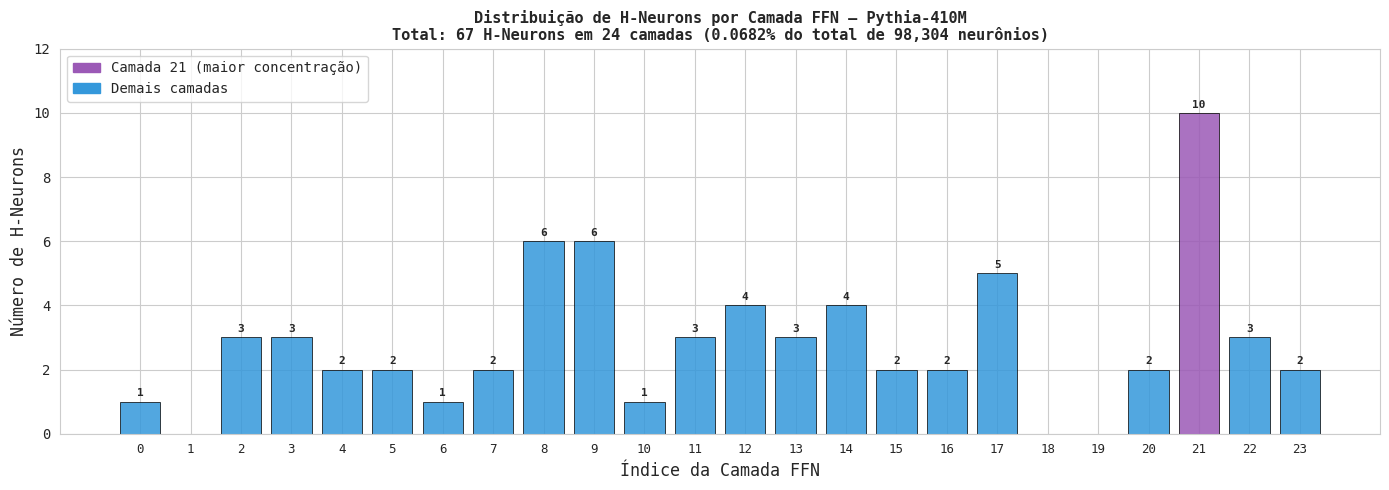

✓ Figura 1 salva: /content/drive/MyDrive/IA376/h_neurons_project/fig1_h_neurons_por_camada.png


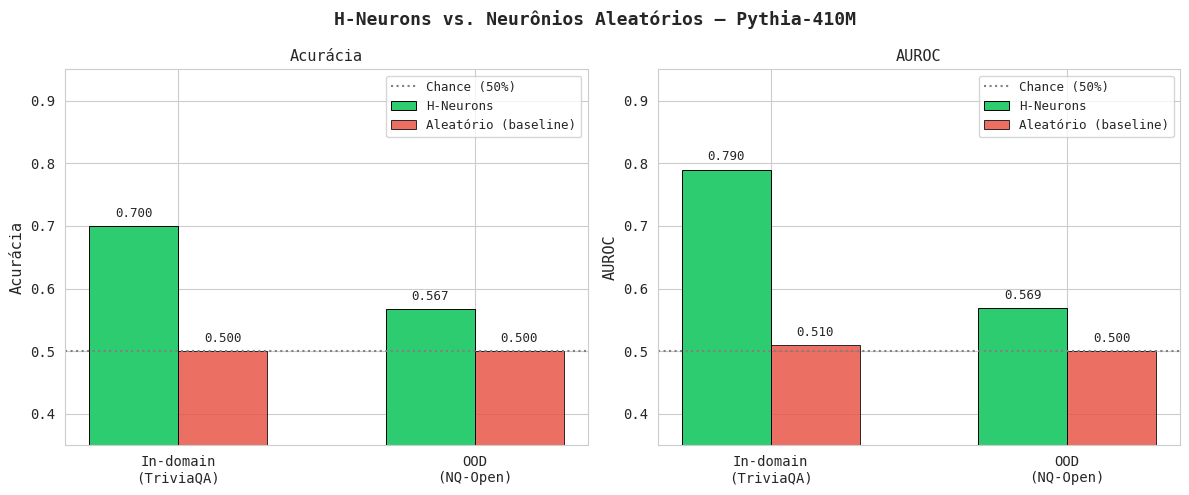

✓ Figura 2 salva: /content/drive/MyDrive/IA376/h_neurons_project/fig2_h_neurons_vs_baseline.png


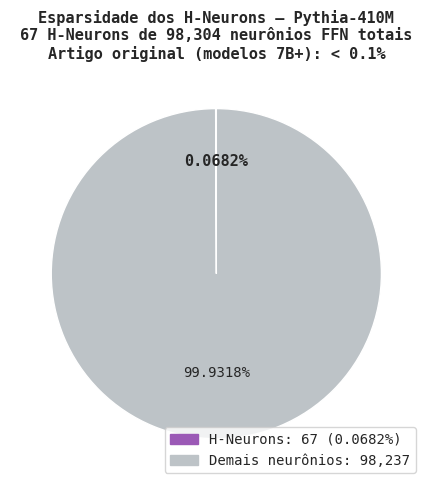

✓ Figura 3 salva: /content/drive/MyDrive/IA376/h_neurons_project/fig3_esparsidade.png

TABELA DE RESULTADOS — PYTHIA-410M
Parâmetro                           Valor
--------------------------------------------------------------
Parâmetros totais                   405,334,016
Neurônios FFN totais                98,304
Camadas FFN                         24
H-Neurons identificados             67
H-Neurons (% do total)              0.0682%
Referência artigo original          < 0.1000%
--------------------------------------------------------------
Acurácia in-domain (TriviaQA)       0.7000
Acurácia baseline aleatório         0.5000
Ganho de acurácia                   +0.2000
--------------------------------------------------------------
AUROC in-domain (TriviaQA)          0.7900
AUROC baseline aleatório            0.5100
Ganho de AUROC                      +0.2800
--------------------------------------------------------------
Acurácia OOD (NQ-Open)              0.5667
AUROC OOD (NQ-Open)   

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# ============================================================
# VISUALIZAÇÕES — PYTHIA-410M
# Gera gráficos e tabelas com os resultados já salvos no Drive
# Pode rodar independentemente dos outros modelos
# ============================================================

# Carrega o arquivo de resultados finais
results_path = f"{RESULTS_DIR}/pythia-410m_final_results.json"
with open(results_path) as f:
    r = json.load(f)

print(f"✓ Resultados carregados: {results_path}")
print(f"  Modelo: {r['model_id']}")
print(f"  H-Neurons: {r['n_h_neurons']} ({r['pct_h_neurons']:.4f}%)")

# Estilo visual
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "monospace"
COLORS = {
    "h_neurons": "#2ecc71",
    "random":    "#e74c3c",
    "reference": "#e67e22",
    "layer":     "#3498db",
    "highlight": "#9b59b6",
}

# ============================================================
# FIGURA 1 — Distribuição de H-Neurons por camada
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))

by_layer = r["h_neurons_by_layer"]
n_layers = r["n_ffn_layers"]
layers = list(range(n_layers))
counts = [by_layer.get(str(l), 0) for l in layers]

# Identifica a camada com mais H-Neurons para destacar
max_layer = int(max(by_layer, key=lambda k: by_layer[k]))
bar_colors = [COLORS["highlight"] if l == max_layer
              else COLORS["layer"] for l in layers]

bars = ax.bar(layers, counts, color=bar_colors,
              edgecolor="black", linewidth=0.6, alpha=0.85)

# Anota o valor em cada barra não-zero
for bar, count in zip(bars, counts):
    if count > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                str(count), ha="center", va="bottom",
                fontsize=8, fontweight="bold")

ax.set_xlabel("Índice da Camada FFN", fontsize=12)
ax.set_ylabel("Número de H-Neurons", fontsize=12)
ax.set_title(
    f"Distribuição de H-Neurons por Camada FFN — Pythia-410M\n"
    f"Total: {r['n_h_neurons']} H-Neurons em {n_layers} camadas "
    f"({r['pct_h_neurons']:.4f}% do total de {r['total_ffn_neurons']:,} neurônios)",
    fontsize=11, fontweight="bold"
)
ax.set_xticks(layers)
ax.set_xticklabels([str(l) for l in layers], fontsize=9)

# Legenda
patch_h = mpatches.Patch(color=COLORS["highlight"],
                          label=f"Camada {max_layer} (maior concentração)")
patch_n = mpatches.Patch(color=COLORS["layer"],
                          label="Demais camadas")
ax.legend(handles=[patch_h, patch_n], fontsize=10)
ax.set_ylim(0, max(counts) + 2)

plt.tight_layout()
fig1_path = f"{RESULTS_DIR}/fig1_h_neurons_por_camada.png"
plt.savefig(fig1_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Figura 1 salva: {fig1_path}")

# ============================================================
# FIGURA 2 — H-Neurons vs. Baseline: Acurácia e AUROC
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("H-Neurons vs. Neurônios Aleatórios — Pythia-410M",
             fontsize=13, fontweight="bold")

metrics = ["accuracy", "auroc"]
labels  = ["Acurácia", "AUROC"]
domains = ["In-domain\n(TriviaQA)", "OOD\n(NQ-Open)"]

for ax, metric, label in zip(axes, metrics, labels):

    # Valores H-Neurons
    val_h_indomain = r["indomain_h_neurons"][metric]
    val_h_ood      = r["ood_nq_open"].get(
        f"nq_open_{metric}", None)

    # Valores baseline aleatório (só in-domain disponível)
    val_rand = r["indomain_random"][metric]

    x = np.array([0, 1])
    width = 0.3

    bars_h = ax.bar(x - width/2,
                    [val_h_indomain,
                     val_h_ood if val_h_ood else 0],
                    width, label="H-Neurons",
                    color=COLORS["h_neurons"],
                    edgecolor="black", linewidth=0.7)

    bars_r = ax.bar(x + width/2,
                    [val_rand, 0.50],
                    width, label="Aleatório (baseline)",
                    color=COLORS["random"],
                    edgecolor="black", linewidth=0.7,
                    alpha=0.8)

    # Linha de chance
    ax.axhline(0.5, color="gray", linestyle=":",
               linewidth=1.5, label="Chance (50%)")

    # Anota valores nas barras
    for bar in list(bars_h) + list(bars_r):
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    h + 0.01, f"{h:.3f}",
                    ha="center", va="bottom", fontsize=9)

    ax.set_ylabel(label, fontsize=11)
    ax.set_title(label, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(domains, fontsize=10)
    ax.set_ylim(0.35, 0.95)
    ax.legend(fontsize=9)

plt.tight_layout()
fig2_path = f"{RESULTS_DIR}/fig2_h_neurons_vs_baseline.png"
plt.savefig(fig2_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Figura 2 salva: {fig2_path}")

# ============================================================
# FIGURA 3 — Esparsidade: H-Neurons vs. total de neurônios
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

total = r["total_ffn_neurons"]
n_h   = r["n_h_neurons"]
n_rest = total - n_h

sizes  = [n_h, n_rest]
clrs   = [COLORS["highlight"], "#bdc3c7"]
explode = (0.08, 0)

wedges, texts, autotexts = ax.pie(
    sizes,
    explode=explode,
    colors=clrs,
    autopct="%1.4f%%",
    startangle=90,
    textprops={"fontsize": 10},
)
autotexts[0].set_fontweight("bold")
autotexts[0].set_fontsize(11)

ax.set_title(
    f"Esparsidade dos H-Neurons — Pythia-410M\n"
    f"{n_h} H-Neurons de {total:,} neurônios FFN totais\n"
    f"Artigo original (modelos 7B+): < 0.1%",
    fontsize=11, fontweight="bold"
)

patch_h = mpatches.Patch(color=COLORS["highlight"],
                          label=f"H-Neurons: {n_h} ({r['pct_h_neurons']:.4f}%)")
patch_r = mpatches.Patch(color="#bdc3c7",
                          label=f"Demais neurônios: {n_rest:,}")
ax.legend(handles=[patch_h, patch_r], fontsize=10,
          loc="lower right")

plt.tight_layout()
fig3_path = f"{RESULTS_DIR}/fig3_esparsidade.png"
plt.savefig(fig3_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Figura 3 salva: {fig3_path}")

# ============================================================
# TABELA — Resumo completo dos resultados
# ============================================================
print("\n" + "=" * 62)
print("TABELA DE RESULTADOS — PYTHIA-410M")
print("=" * 62)
print(f"{'Parâmetro':<35} {'Valor'}")
print("-" * 62)
print(f"{'Parâmetros totais':<35} {r['total_parameters']:,}")
print(f"{'Neurônios FFN totais':<35} {r['total_ffn_neurons']:,}")
print(f"{'Camadas FFN':<35} {r['n_ffn_layers']}")
print(f"{'H-Neurons identificados':<35} {r['n_h_neurons']}")
print(f"{'H-Neurons (% do total)':<35} {r['pct_h_neurons']:.4f}%")
print(f"{'Referência artigo original':<35} < 0.1000%")
print("-" * 62)
print(f"{'Acurácia in-domain (TriviaQA)':<35} {r['indomain_h_neurons']['accuracy']:.4f}")
print(f"{'Acurácia baseline aleatório':<35} {r['indomain_random']['accuracy']:.4f}")
print(f"{'Ganho de acurácia':<35} +{r['indomain_h_neurons']['accuracy'] - r['indomain_random']['accuracy']:.4f}")
print("-" * 62)
print(f"{'AUROC in-domain (TriviaQA)':<35} {r['indomain_h_neurons']['auroc']:.4f}")
print(f"{'AUROC baseline aleatório':<35} {r['indomain_random']['auroc']:.4f}")
print(f"{'Ganho de AUROC':<35} +{r['indomain_h_neurons']['auroc'] - r['indomain_random']['auroc']:.4f}")
print("-" * 62)
ood_acc   = r["ood_nq_open"].get("nq_open_accuracy") or 0
ood_auroc = r["ood_nq_open"].get("nq_open_auroc") or 0
print(f"{'Acurácia OOD (NQ-Open)':<35} {ood_acc:.4f}")
print(f"{'AUROC OOD (NQ-Open)':<35} {ood_auroc:.4f}")
print(f"{'Camada com mais H-Neurons':<35} Camada {max_layer} ({max(counts)} neurônios)")
print("=" * 62)
print(f"\n✓ Figuras salvas em: {RESULTS_DIR}")
print("  fig1_h_neurons_por_camada.png")
print("  fig2_h_neurons_vs_baseline.png")
print("  fig3_esparsidade.png")

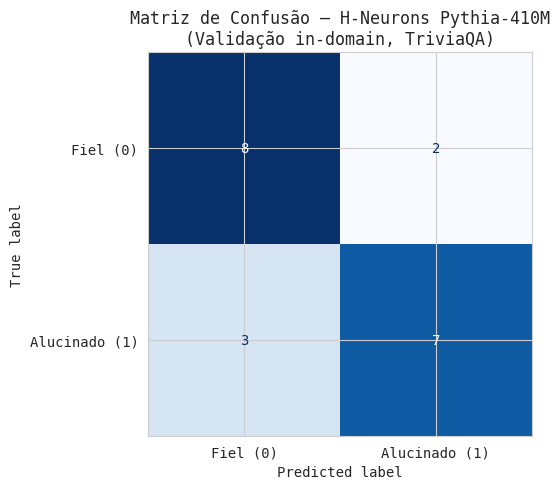

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fiel (0)", "Alucinado (1)"]
)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de Confusão — H-Neurons Pythia-410M\n(Validação in-domain, TriviaQA)")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig4_matriz_confusao.png", dpi=150, bbox_inches="tight")
plt.show()

## Bloco 10 — Análise Comparativa entre Modelos

**Este bloco só deve ser executado após rodar os Blocos 1–9 para os três modelos (pythia-70m, pythia-160m, pythia-410m).**

Lê os arquivos de resultados salvos e gera visualizações comparativas que respondem às hipóteses do projeto:

- **H1:** H-Neurons existem nos três modelos? (gráfico de acurácia vs. baseline)
- **H2:** A acurácia aumenta com o tamanho do modelo? (curva de escala)
- **H3:** A proporção de H-Neurons se mantém? (análise de esparsidade)
- **Bônus:** Os H-Neurons se concentram nas mesmas camadas relativas? (heatmap)

In [ ]:
# Carrega resultados dos três modelos
results_dir = CONFIG["results_dir"]
model_names = ["pythia-70m", "pythia-160m", "pythia-410m"]

all_results = {}
for model_name in model_names:
    path = f"{results_dir}/{model_name}_final_results.json"
    if os.path.exists(path):
        with open(path) as f:
            all_results[model_name] = json.load(f)
        print(f"✓ Carregado: {model_name}")
    else:
        print(f"⚠ Não encontrado: {path} — execute o pipeline para este modelo primeiro")

available_models = list(all_results.keys())
print(f"\nModelos disponíveis para análise: {available_models}")

In [ ]:
# === FIGURA 1: Acurácia e AUROC por modelo (H-Neurons vs. Baseline) ===

if len(available_models) < 1:
    print("Nenhum resultado disponível ainda.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("H-Neurons vs. Neurônios Aleatórios — Família Pythia",
                 fontsize=14, fontweight="bold")

    # Prepara dados para o gráfico
    params = [all_results[m]["total_parameters"] / 1e6 for m in available_models]  # em milhões
    acc_h = [all_results[m]["indomain_h_neurons"]["accuracy"] for m in available_models]
    acc_r = [all_results[m]["indomain_random"]["accuracy"] for m in available_models]
    auroc_h = [all_results[m]["indomain_h_neurons"]["auroc"] for m in available_models]
    auroc_r = [all_results[m]["indomain_random"]["auroc"] for m in available_models]

    # Subplot 1: Acurácia
    ax = axes[0]
    ax.plot(params, acc_h, 'o-', color='#2ecc71', linewidth=2,
            markersize=8, label='H-Neurons')
    ax.plot(params, acc_r, 's--', color='#e74c3c', linewidth=2,
            markersize=8, label='Aleatório (baseline)')
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Chance (50%)')
    ax.set_xlabel("Parâmetros do modelo (M)", fontsize=11)
    ax.set_ylabel("Acurácia", fontsize=11)
    ax.set_title("Acurácia in-domain (TriviaQA)", fontsize=11)
    ax.legend()
    ax.set_ylim(0.4, 1.0)
    ax.grid(True, alpha=0.3)

    for i, m in enumerate(available_models):
        ax.annotate(m.split('-')[1], (params[i], acc_h[i]),
                    textcoords="offset points", xytext=(0, 10), fontsize=9)

    # Subplot 2: AUROC
    ax = axes[1]
    ax.plot(params, auroc_h, 'o-', color='#2ecc71', linewidth=2,
            markersize=8, label='H-Neurons')
    ax.plot(params, auroc_r, 's--', color='#e74c3c', linewidth=2,
            markersize=8, label='Aleatório (baseline)')
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Chance (50%)')
    ax.set_xlabel("Parâmetros do modelo (M)", fontsize=11)
    ax.set_ylabel("AUROC", fontsize=11)
    ax.set_title("AUROC in-domain (TriviaQA)", fontsize=11)
    ax.legend()
    ax.set_ylim(0.4, 1.0)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig_path = f"{results_dir}/fig1_accuracy_by_scale.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Figura 1 salva em: {fig_path}")

In [ ]:
# === FIGURA 2: Esparsidade dos H-Neurons por modelo ===

if len(available_models) >= 1:
    fig, ax = plt.subplots(figsize=(10, 5))

    pct_h = [all_results[m]["pct_h_neurons"] for m in available_models]
    n_h = [all_results[m]["n_h_neurons"] for m in available_models]
    colors = ['#3498db', '#e67e22', '#9b59b6']

    bars = ax.bar(available_models, pct_h, color=colors[:len(available_models)],
                  alpha=0.8, edgecolor='black', linewidth=0.8)

    # Linha de referência: 0.1% (limiar do artigo original)
    ax.axhline(0.1, color='red', linestyle='--', linewidth=1.5,
               label='Limiar artigo original (0.1%)')

    # Anota o número absoluto de H-Neurons em cada barra
    for bar, n in zip(bars, n_h):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{n} neurônios', ha='center', va='bottom', fontsize=10)

    ax.set_xlabel("Modelo", fontsize=11)
    ax.set_ylabel("H-Neurons (% do total)", fontsize=11)
    ax.set_title("Esparsidade dos H-Neurons por Escala de Modelo", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    fig_path = f"{results_dir}/fig2_sparsity_by_scale.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Figura 2 salva em: {fig_path}")

In [ ]:
# === FIGURA 3: Distribuição de H-Neurons por camada (heatmap) ===
# Mostra em quais camadas FFN os H-Neurons se concentram
# e se esse padrão é consistente entre os modelos

if len(available_models) >= 1:
    fig, axes = plt.subplots(1, len(available_models),
                              figsize=(5 * len(available_models), 5))

    if len(available_models) == 1:
        axes = [axes]  # garante que axes seja sempre lista

    for ax, model_name in zip(axes, available_models):
        res = all_results[model_name]
        by_layer = res["h_neurons_by_layer"]

        # Converte para arrays ordenados por índice de camada
        layers = sorted([int(k) for k in by_layer.keys()])
        counts = [by_layer[str(l)] for l in layers]

        # Normaliza pelo número de neurônios por camada para comparação justa
        total_per_layer = res["total_ffn_neurons"] / max(len(layers), 1)
        pcts = [c / total_per_layer * 100 for c in counts]

        # Heatmap vertical: camada no eixo y, intensidade = % de H-Neurons
        heatmap_data = np.array(pcts).reshape(-1, 1)
        sns.heatmap(heatmap_data, ax=ax, cmap='YlOrRd',
                    yticklabels=[f"L{l}" for l in layers],
                    xticklabels=["%"],
                    annot=True, fmt='.2f', cbar=True)

        ax.set_title(f"{model_name}\n({res['total_parameters']/1e6:.0f}M params)",
                     fontsize=11)
        ax.set_ylabel("Camada FFN")

    fig.suptitle("Distribuição de H-Neurons por Camada FFN",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    fig_path = f"{results_dir}/fig3_h_neurons_by_layer.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Figura 3 salva em: {fig_path}")

In [ ]:
# === TABELA FINAL: Resumo comparativo ===

print("\n" + "=" * 90)
print("TABELA COMPARATIVA FINAL — H-NEURONS NA FAMÍLIA PYTHIA")
print("=" * 90)
print(f"{'Modelo':<18} {'Params':<10} {'H-Neur.':<10} {'%Total':<10} "
      f"{'Acc H':<10} {'Acc Rand':<10} {'AUROC H':<10} {'AUROC OOD'}")
print("-" * 90)

for model_name in available_models:
    r = all_results[model_name]
    ood_auroc = r["ood_nq_open"].get("nq_open_auroc") or 0.0
    print(
        f"{model_name:<18} "
        f"{r['total_parameters']/1e6:.0f}M{'':<5} "
        f"{r['n_h_neurons']:<10} "
        f"{r['pct_h_neurons']:.4f}%{'':<2} "
        f"{r['indomain_h_neurons']['accuracy']:.4f}{'':<4} "
        f"{r['indomain_random']['accuracy']:.4f}{'':<4} "
        f"{r['indomain_h_neurons']['auroc']:.4f}{'':<4} "
        f"{ood_auroc:.4f}"
    )

print("=" * 90)
print("\nInterpretação:")
print("  Acc H > Acc Rand → H-Neurons carregam sinal real de alucinação")
print("  %Total próximo de 0.1% → esparsidade compatível com o artigo original")
print("  AUROC OOD > 0.5 → generalização para domínios não vistos")
print("  Tendência crescente com escala → fenômeno se fortalece com mais parâmetros")

### Template de Discussão dos Resultados

Use esta seção para registrar a interpretação dos resultados encontrados.

**Sobre a existência de H-Neurons (H1):**
> *[Preencher após execução: os H-Neurons foram identificados nos três modelos? A acurácia supera o baseline aleatório em todos os casos?]*

**Sobre a relação com escala (H2):**
> *[Preencher: a acurácia e o AUROC aumentam monotonicamente de 70M para 410M? Qual a magnitude do ganho?]*

**Sobre a esparsidade:**
> *[Preencher: a proporção de H-Neurons (% do total) é consistente entre os modelos, ou varia? Está próxima do limiar de 0.1% reportado no artigo para modelos maiores?]*

**Sobre a distribuição por camada:**
> *[Preencher: os H-Neurons se concentram em camadas específicas? O padrão é consistente entre os três modelos?]*

**Sobre a generalização (H3):**
> *[Preencher: o AUROC no NQ-Open supera 0.5? Qual a magnitude da queda em relação ao in-domain?]*

**Conclusão geral:**
> *[Preencher: os resultados suportam H1 (existência), H2 (escala) e H3 (generalização)? O que isso implica sobre a natureza dos H-Neurons em modelos pequenos?]*

---
*Notebook desenvolvido para o projeto da disciplina IA376N — Inteligência Artificial Generativa, UNICAMP 2026.*
*Baseado em: Gao et al. (2025). H-Neurons: On the Existence, Impact, and Origin of Hallucination-Associated Neurons in LLMs. arXiv:2512.01797.*